# RUL Prediction: Hybrid Transformer Models
## LSTM-Transformer, GRU-Transformer, CNN-Transformer Architectures
**Owen's Implementation - Team Deep Learning Project**

# FD001 Dataset - RUL Prediction with Hybrid Transformers

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)

SEED = 1234

def seed_everything(seed=1234):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"
    
    random.seed(seed)
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"Seed set to: {SEED}")

Using device: mps
Seed set to: 1234


In [ ]:
# If running in Colab, authenticate and mount Google Drive

# from google.colab import auth
# auth.authenticate_user()


## Part 1: Exploratory Data Analysis (EDA)

In [9]:
### Local paths to the processed NASA datasets ###

# Data Cleaning 1: RUL only, no feature engineering, normalization
train_df_fd001_rul = pd.read_csv('../data/processed-nasa-data/data_cleaning_1/linear_rul_1/train_processed_rul_only_fd001.csv')
test_df_fd001_rul = pd.read_csv('../data/processed-nasa-data/data_cleaning_1/linear_rul_1/test_processed_rul_only_fd001.csv')

# Data Cleaning 2: RUL only, no feature engineering, no normalization
train_df_fd001_nonorm = pd.read_csv('../data/processed-nasa-data/data_cleaning_1/linear_rul_no_norm_0/train_processed_rul_only_fd001.csv')
test_df_fd001_nonorm = pd.read_csv('../data/processed-nasa-data/data_cleaning_1/linear_rul_no_norm_0/test_processed_rul_only_fd001.csv')

# Data Cleaning 3: Piecewise RUL, no feature engineering, normalization (capped at 150)
train_df_fd001_piecewise = pd.read_csv('../data/processed-nasa-data/data_cleaning_1/piecewise_rul_2/train_processed_rul_piecewise_150_fd001.csv')
test_df_fd001_piecewise = pd.read_csv('../data/processed-nasa-data/data_cleaning_1/piecewise_rul_2/test_processed_rul_piecewise_150_fd001.csv')

# Feature Engineering 1: Feature engineered using High Correlation (Manual) method, normalization
train_df_fd001_fe_manual = pd.read_csv('../data/processed-nasa-data/feature_engineering_2/high_correlation_2/manual_fd001_1/train_fd001_drop_s14_s12.csv')
test_df_fd001_fe_manual = pd.read_csv('../data/processed-nasa-data/feature_engineering_2/high_correlation_2/manual_fd001_1/test_fd001_drop_s14_s12.csv')

# Feature Engineering 2: Feature engineered using Low Variance method, normalization
train_df_fd001_fe_lowvar = pd.read_csv('../data/processed-nasa-data/feature_engineering_2/low_variance_1/train_fd001_low_variance_1.csv')
test_df_fd001_fe_lowvar = pd.read_csv('../data/processed-nasa-data/feature_engineering_2/low_variance_1/test_fd001_low_variance_1.csv')

eda_data = []
datasets = [
    ("Linear RUL (No Norm)", train_df_fd001_nonorm, test_df_fd001_nonorm),
    ("Linear RUL (Normalized)", train_df_fd001_rul, test_df_fd001_rul),
    ("Piecewise RUL (150)", train_df_fd001_piecewise, test_df_fd001_piecewise),
    ("FE - Manual (Corr)", train_df_fd001_fe_manual, test_df_fd001_fe_manual),
    ("FE - Low Variance", train_df_fd001_fe_lowvar, test_df_fd001_fe_lowvar),
]

for name, train_df, test_df in datasets:
    eda_data.append({
        'Dataset': name,
        'Train Rows': f"{train_df.shape[0]:,}",
        'Test Rows': f"{test_df.shape[0]:,}",
        'Features': train_df.shape[1],
        'Engines (Train)': train_df['id'].nunique(),
        'Engines (Test)': test_df['id'].nunique(),
        'RUL Range': f"[{train_df['RUL'].min()}, {train_df['RUL'].max()}]",
    })

eda_df = pd.DataFrame(eda_data)
print("\n" + "="*110)
print(eda_df.to_string(index=False))
print("="*110 + "\n")


                Dataset Train Rows Test Rows  Features  Engines (Train)  Engines (Test) RUL Range
   Linear RUL (No Norm)     20,631    13,096        27              100             100  [0, 361]
Linear RUL (Normalized)     20,631    13,096        27              100             100  [0, 361]
    Piecewise RUL (150)     20,631    13,096        27              100             100  [0, 150]
     FE - Manual (Corr)     20,631    13,096        18              100             100  [0, 150]
      FE - Low Variance     20,631    13,096        20              100             100  [0, 150]



### Simple EDA on the RUL dataset to understand the data distribution, feature importance, and potential correlations.

/var/folders/59/qbzfw51d345c84sls3kvv_300000gn/T/ipykernel_8463/2199606449.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 1].boxplot(rul_data, labels=dataset_names, patch_artist=True)


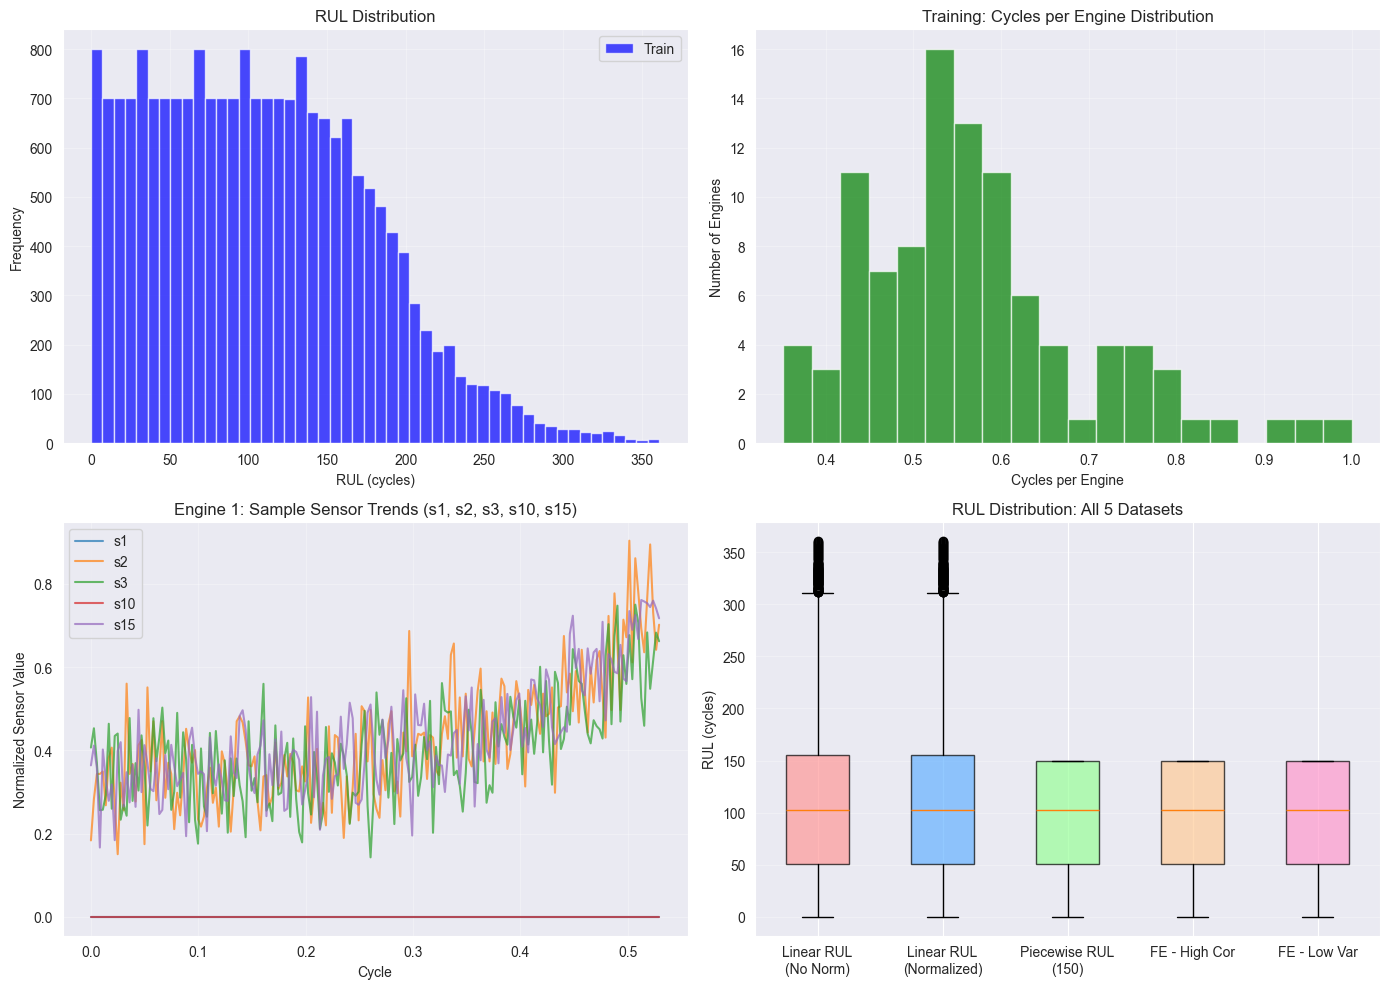

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. RUL Distribution
axes[0, 0].hist(train_df_fd001_rul['RUL'], bins=50, alpha=0.7, color='blue', label='Train')
axes[0, 0].set_xlabel('RUL (cycles)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('RUL Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Cycles per Engine
train_cycles_dist = train_df_fd001_rul.groupby('id')['cycle'].max()
axes[0, 1].hist(train_cycles_dist, bins=20, color='green', alpha=0.7)
axes[0, 1].set_xlabel('Cycles per Engine')
axes[0, 1].set_ylabel('Number of Engines')
axes[0, 1].set_title('Training: Cycles per Engine Distribution')
axes[0, 1].grid(True, alpha=0.3)

# 3. Sample sensor trends (Engine 1)
engine1_data = train_df_fd001_rul[train_df_fd001_rul['id'] == 1].sort_values('cycle')
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s1'], label='s1', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s2'], label='s2', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s3'], label='s3', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s10'], label='s10', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s15'], label='s15', alpha=0.7)
axes[1, 0].set_xlabel('Cycle')
axes[1, 0].set_ylabel('Normalized Sensor Value')
axes[1, 0].set_title('Engine 1: Sample Sensor Trends (s1, s2, s3, s10, s15)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. RUL Distribution Box Plot across all 5 datasets
rul_data = [
    train_df_fd001_nonorm['RUL'].values,
    train_df_fd001_rul['RUL'].values,
    train_df_fd001_piecewise['RUL'].values,
    train_df_fd001_fe_manual['RUL'].values,
    train_df_fd001_fe_lowvar['RUL'].values,
]

dataset_names = [
    'Linear RUL\n(No Norm)',
    'Linear RUL\n(Normalized)',
    'Piecewise RUL\n(150)',
    'FE - High Cor',
    'FE - Low Var',
]

bp = axes[1, 1].boxplot(rul_data, labels=dataset_names, patch_artist=True)

# Customize box plot colors
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1, 1].set_ylabel('RUL (cycles)')
axes[1, 1].set_title('RUL Distribution: All 5 Datasets')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Part 2: Data Preparation & Sequence Creation

**Why do we need to create sequences for RUL prediction?**
- RUL prediction is a time-series forecasting problem where we want to predict the remaining useful life of a machine based on its historical sensor readings.
- Thus, we **cannot treat each data point independently or randomly shuffle the data,** as we would in a typical supervised learning problem.
- Creating sequences allows us to capture temporal dependencies and patterns in the data, which are crucial for accurate RUL prediction.
- By feeding sequences of sensor readings into our models, we can learn how the machine's condition evolves over time and make more informed predictions about its future state.
- In the next steps, we will preprocess the data, create sequences of sensor readings, and prepare the datasets for training our hybrid transformer models.

In [22]:
### Dataset and DataLoader Creation for All 5 Datasets ###

SEQUENCE_LENGTH = 50
BATCH_SIZE = 64
TRAIN_TEST_SPLIT = 0.8  # 80% of training data for training, 20% for validation

class RULDataset(Dataset):
    """PyTorch Dataset for RUL sequence prediction"""
    def __init__(self, df, sequence_length=30, feature_cols=None):
        """
        Args:
            df: DataFrame with columns: id, cycle, feature_cols, and RUL
            sequence_length: Length of input sequences
            feature_cols: List of feature column names (auto-detected if None)
        """
        self.sequence_length = sequence_length
        
        # Auto-detect feature columns if not provided
        if feature_cols is None:
            self.feature_cols = [col for col in df.columns if col[0] == 's' and col[1:].isdigit()]
        else:
            self.feature_cols = feature_cols
            
        self.sequences = []
        self.labels = []
        
        # Create sequences per engine
        for engine_id in df['id'].unique():
            engine_data = df[df['id'] == engine_id].sort_values('cycle').reset_index(drop=True)
            features = engine_data[self.feature_cols].values
            rul = engine_data['RUL'].values
            
            # Create overlapping sequences
            for i in range(len(engine_data) - sequence_length):
                self.sequences.append(features[i:i+sequence_length])
                self.labels.append(rul[i+sequence_length])

        self.sequences = np.array(self.sequences, dtype=np.float32)
        self.labels = np.array(self.labels, dtype=np.float32)
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return torch.tensor(self.sequences[idx]), torch.tensor(self.labels[idx])

# Dictionary to store all datasets and loaders
datasets_config = {
    'Linear RUL (No Norm)': (train_df_fd001_nonorm, test_df_fd001_nonorm),
    'Linear RUL (Normalized)': (train_df_fd001_rul, test_df_fd001_rul),
    'Piecewise RUL (150)': (train_df_fd001_piecewise, test_df_fd001_piecewise),
    'FE - Manual (Corr)': (train_df_fd001_fe_manual, test_df_fd001_fe_manual),
    'FE - Low Variance': (train_df_fd001_fe_lowvar, test_df_fd001_fe_lowvar),
}

# Create datasets and loaders for each configuration
train_loaders = {}
val_loaders = {}
test_loaders = {}
dataset_info = []

for dataset_name, (train_df, test_df) in datasets_config.items():
    # Auto-detect feature columns for this dataset
    dataset_sensor_cols = [col for col in train_df.columns if col[0] == 's' and col[1:].isdigit()]
    num_features = len(dataset_sensor_cols)
    
    # Create base datasets (feature_cols will be auto-detected)
    train_dataset = RULDataset(train_df, SEQUENCE_LENGTH)
    test_dataset = RULDataset(test_df, SEQUENCE_LENGTH)
    
    # Split training set into train/validation
    train_size = int(TRAIN_TEST_SPLIT * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_split, val_split = random_split(
        train_dataset, 
        [train_size, val_size],
        generator=torch.Generator().manual_seed(SEED)
    )
    
    # Create data loaders
    train_loader = DataLoader(train_split, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_split, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # Store loaders
    train_loaders[dataset_name] = train_loader
    val_loaders[dataset_name] = val_loader
    test_loaders[dataset_name] = test_loader
    
    # Store info for summary
    dataset_info.append({
        'Dataset': dataset_name,
        'Features': num_features,
        'Sequence Length': SEQUENCE_LENGTH,
        'Train Seqs': train_size,
        'Val Seqs': val_size,
        'Test Seqs': len(test_dataset),     ## Test Seqs = Total Test Dataset - (number of ID x SEQUENCE_LENGTH )
        'X Shape (Batch)': f"({BATCH_SIZE}, {SEQUENCE_LENGTH}, {num_features})",
        'Y Shape (Batch)': f"({BATCH_SIZE},)",
    })

summary_df = pd.DataFrame(dataset_info)     ## to use dataloader, train_loaders[dataset_name]
print("\n" + "="*130)
print("Dataset & DataLoader Summary")
print("="*130)
print(summary_df.to_string(index=False))
print("="*130)



Dataset & DataLoader Summary
                Dataset  Features  Sequence Length  Train Seqs  Val Seqs  Test Seqs X Shape (Batch) Y Shape (Batch)
   Linear RUL (No Norm)        21               50       12504      3127       8162    (64, 50, 21)           (64,)
Linear RUL (Normalized)        21               50       12504      3127       8162    (64, 50, 21)           (64,)
    Piecewise RUL (150)        21               50       12504      3127       8162    (64, 50, 21)           (64,)
     FE - Manual (Corr)        13               50       12504      3127       8162    (64, 50, 13)           (64,)
      FE - Low Variance        15               50       12504      3127       8162    (64, 50, 15)           (64,)


## Part 3: Model Architectures

### Overview: Hybrid Transformer Models

**Concept:** Combine RNN/CNN feature extraction with Transformer attention for improved sequence modeling.

Architecture variants:
1. **LSTM-Transformer:** LSTM feature extraction → Transformer refinement
2. **GRU-Transformer:** GRU feature extraction → Transformer refinement  
3. **CNN-Transformer:** 1D CNN feature extraction → Transformer refinement

Reference:
- [LSTM-Transformer Paper](https://arxiv.org/abs/2002.04745)
- [GRU-Transformer Paper](https://arxiv.org/abs/2103.00020)
- [CNN-Transformer Paper](https://arxiv.org/abs/2106.00020)
- [PyTorch Transformer Documentation](https://docs.pytorch.org/docs/stable/generated/torch.nn.TransformerEncoder.html)
- [Attention Is All You Need Paper](https://arxiv.org/abs/1706.03762)

In [24]:
# ============ BASE COMPONENTS ============

class TransformerEncoder(nn.Module):
    """Standard Transformer Encoder Block
    
    Arguments:
    - d_model: Dimension of the input and output features
    - nhead: Number of attention heads
    - dim_feedforward: Dimension of the feed-forward network
    - dropout: Dropout rate

    Architecture:
    1. Multi-head self-attention
    2. Add & Norm
    3. Position-wise feed-forward network
    4. Add & Norm
    """
    def __init__(self, d_model, nhead, dim_feedforward, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Linear(dim_feedforward, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # x shape: (batch, seq_len, d_model)
        # Self-attention
        attn_out, _ = self.attention(x, x, x)
        x = self.norm1(x + self.dropout(attn_out))
        
        # Feed-forward
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))
        
        return x

# ============ MODEL 1: LSTM-Transformer ============

class LSTMTransformer(nn.Module):
    """
    LSTM-Transformer Model
    
    Architecture:
    1. Input: (batch, seq_len, num_features)
    2. LSTM layers for temporal feature extraction
    3. Transformer encoder for attention-based modeling
    4. Global average pooling
    5. FC layers for RUL prediction
    """
    
    def __init__(self, num_features, lstm_hidden=64, num_lstm_layers=2, 
                d_model=64, nhead=4, num_transformer_layers=2, dropout=0.1):
        super().__init__()
        
        self.num_features = num_features
        self.lstm_hidden = lstm_hidden
        self.d_model = d_model
        
        # LSTM Feature Extraction
        self.lstm = nn.LSTM(
            input_size=num_features,
            hidden_size=lstm_hidden,
            num_layers=num_lstm_layers,
            batch_first=True,
            dropout=dropout if num_lstm_layers > 1 else 0,
            bidirectional=True
        )
        
        lstm_output_dim = lstm_hidden * 2  # Bidirectional
        
        self.projection = nn.Linear(lstm_output_dim, d_model)
        self.transformer_layers = nn.ModuleList([           # Transformer Encoder Stack
            TransformerEncoder(d_model, nhead, d_model*4, dropout)
            for _ in range(num_transformer_layers)
        ])
        self.fc1 = nn.Linear(d_model, 32)
        self.fc2 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # x: (batch, seq_len, num_features)
        lstm_out, _ = self.lstm(x)  # (batch, seq_len, lstm_hidden*2)
        x = self.projection(lstm_out)  # (batch, seq_len, d_model)
        for transformer in self.transformer_layers:
            x = transformer(x)
        
        x = x.mean(dim=1)  # (batch, d_model)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)  # (batch, 1)
        
        return x.squeeze(1)

# ============ MODEL 2: GRU-Transformer ============

class GRUTransformer(nn.Module):
    """
    GRU-Transformer Model
    
    Architecture:
    1. Input: (batch, seq_len, num_features)
    2. GRU layers for temporal feature extraction
    3. Transformer encoder for attention-based modeling
    4. Global average pooling
    5. FC layers for RUL prediction
    """
    
    def __init__(self, num_features, gru_hidden=64, num_gru_layers=2, 
                d_model=64, nhead=4, num_transformer_layers=2, dropout=0.1):
        super().__init__()
        
        self.num_features = num_features
        self.gru_hidden = gru_hidden
        self.d_model = d_model
        
        # GRU Feature Extraction
        self.gru = nn.GRU(
            input_size=num_features,
            hidden_size=gru_hidden,
            num_layers=num_gru_layers,
            batch_first=True,
            dropout=dropout if num_gru_layers > 1 else 0,
            bidirectional=True
        )
        
        gru_output_dim = gru_hidden * 2  # Bidirectional
        
        self.projection = nn.Linear(gru_output_dim, d_model)
        self.transformer_layers = nn.ModuleList([
            TransformerEncoder(d_model, nhead, d_model*4, dropout)
            for _ in range(num_transformer_layers)
        ])
        self.fc1 = nn.Linear(d_model, 32)
        self.fc2 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # x: (batch, seq_len, num_features)
        
        gru_out, _ = self.gru(x)  # (batch, seq_len, gru_hidden*2)
        x = self.projection(gru_out)  # (batch, seq_len, d_model)
        
        # Transformer encoder
        for transformer in self.transformer_layers:
            x = transformer(x)
        
        x = x.mean(dim=1)  # (batch, d_model)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)  # (batch, 1)
        
        return x.squeeze(1)

# ============ MODEL 3: CNN-Transformer ============

class CNNTransformer(nn.Module):
    """
    CNN-Transformer Model
    
    Architecture:
    1. Input: (batch, seq_len, num_features)
    2. 1D CNN layers for local feature extraction
    3. Transformer encoder for global attention
    4. Global average pooling
    5. FC layers for RUL prediction
    """
    
    def __init__(self, num_features, num_filters=32, kernel_size=3,
                 d_model=64, nhead=4, num_transformer_layers=2, dropout=0.1):
        super().__init__()
        
        self.num_features = num_features
        self.num_filters = num_filters
        self.d_model = d_model
        
        # 1D CNN Feature Extraction
        self.conv1 = nn.Conv1d(num_features, num_filters, kernel_size=kernel_size, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm1d(num_filters)
        self.conv2 = nn.Conv1d(num_filters, num_filters*2, kernel_size=kernel_size, padding=kernel_size//2)
        self.bn2 = nn.BatchNorm1d(num_filters*2)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveAvgPool1d(None)  # No pooling, keep sequence length
        
        cnn_output_dim = num_filters * 2
        
        self.projection = nn.Linear(cnn_output_dim, d_model)
        self.transformer_layers = nn.ModuleList([
            TransformerEncoder(d_model, nhead, d_model*4, dropout)
            for _ in range(num_transformer_layers)
        ])
        self.fc1 = nn.Linear(d_model, 32)
        self.fc2 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # x: (batch, seq_len, num_features)
        x = x.transpose(1, 2)  # (batch, num_features, seq_len)
        
        # CNN blocks
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))  # (batch, num_filters*2, seq_len)
        x = x.transpose(1, 2)  # (batch, seq_len, num_filters*2)
        x = self.projection(x)  # (batch, seq_len, d_model)
        
        # Transformer encoder
        for transformer in self.transformer_layers:
            x = transformer(x)
        x = x.mean(dim=1)  # (batch, d_model)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)  # (batch, 1)
        
        return x.squeeze(1)


## Part 4: Training Framework & Utilities

In [42]:
# ============ IMPORTS FOR LOGGING AND SAVING ============
import csv
from pathlib import Path
from datetime import datetime

class EarlyStoppingCallback:
    """Early stopping to prevent overfitting"""
    def __init__(self, patience=10, delta=0.001):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_val_loss = None
        self.early_stop = False
    
    def __call__(self, val_loss):
        if self.best_val_loss is None:
            self.best_val_loss = val_loss
        elif val_loss > self.best_val_loss - self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_val_loss = val_loss
            self.counter = 0
        
        return self.early_stop

class ModelTrainer:
    """Training framework for RUL prediction models with logging and model saving"""
    
    def __init__(self, model, device, 
                model_name='Model', 
                dataset_name=None, 
                models_dir='models', 
                logs_dir='logs'):
        self.model = model.to(device)
        self.device = device
        self.model_name = model_name
        self.dataset_name = dataset_name
        self.models_dir = models_dir
        self.logs_dir = logs_dir
        self.history = {'train_loss': [], 'val_loss': [], 'val_mae': [], 'val_rmse': []}
        
        Path(self.models_dir).mkdir(parents=True, exist_ok=True)
        Path(self.logs_dir).mkdir(parents=True, exist_ok=True)
        
        # Initialize training log CSV
        self.log_csv = os.path.join(self.logs_dir, 'training_log.csv')
        self.csv_headers = ['timestamp', 'Dataset', 'Model name', 'Epoch', 'Train Loss', 'Val Loss', 'Val RMSE']
        
        # Create CSV file if it doesn't exist
        if not os.path.exists(self.log_csv):
            with open(self.log_csv, 'w', newline='') as f:
                writer = csv.writer(f)
                writer.writerow(self.csv_headers)
    
    def save_model(self):
        """Save model weights - overwrites previous model with same name"""
        model_filename = f"{self.model_name.replace('-', '_')}_{self.dataset_name.replace(' ', '_').replace('(', '').replace(')', '')}.pth"
        model_path = os.path.join(self.models_dir, model_filename)
        torch.save(self.model.state_dict(), model_path)
        print(f"✅ Model saved: {model_path}")
    
    def log_epoch(self, epoch, train_loss, val_loss, val_rmse):
        """Log epoch metrics to CSV"""
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        with open(self.log_csv, 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([
                timestamp,
                self.dataset_name,
                self.model_name,
                epoch + 1,
                f"{train_loss:.6f}",
                f"{val_loss:.6f}",
                f"{val_rmse:.6f}"
            ])
    
    def train_epoch(self, dataloader, optimizer, loss_fn):
        """Train for one epoch"""
        self.model.train()
        total_loss = 0
        
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
            
            # Forward pass
            predictions = self.model(X_batch)
            loss = loss_fn(predictions, y_batch)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        return total_loss / len(dataloader)
    
    def validate(self, dataloader, loss_fn):
        """Validate on validation set"""
        self.model.eval()
        total_loss = 0
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            for X_batch, y_batch in dataloader:
                X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
                
                predictions = self.model(X_batch)
                loss = loss_fn(predictions, y_batch)
                
                total_loss += loss.item()
                all_preds.extend(predictions.cpu().numpy())
                all_targets.extend(y_batch.cpu().numpy())
        
        avg_loss = total_loss / len(dataloader)
        mae = mean_absolute_error(all_targets, all_preds)
        rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
        
        return avg_loss, mae, rmse
    
    def train(self, train_loader, val_loader, epochs=50, lr=0.001, early_stopping_patience=10):
        """Full training loop with logging"""
        optimizer = optim.Adam(self.model.parameters(), lr=lr)
        loss_fn = nn.MSELoss()
        early_stopping = EarlyStoppingCallback(patience=early_stopping_patience)
        
        print(f"\n{'='*80}")
        print(f"Training {self.model_name} on {self.dataset_name}")
        print(f"{'='*80}")
        print(f"{'Epoch':<8} {'Train Loss':<15} {'Val Loss':<15} {'Val MAE':<12} {'Val RMSE':<12}")
        print(f"{'-'*80}")
        
        for epoch in range(epochs):
            train_loss = self.train_epoch(train_loader, optimizer, loss_fn)
            val_loss, val_mae, val_rmse = self.validate(val_loader, loss_fn)
            
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_mae'].append(val_mae)
            self.history['val_rmse'].append(val_rmse)
            
            # Log this epoch to CSV
            self.log_epoch(epoch, train_loss, val_loss, val_rmse)
            
            if (epoch + 1) % 5 == 0 or epoch == 0:
                print(f"{epoch+1:<8} {train_loss:<15.6f} {val_loss:<15.6f} {val_mae:<12.4f} {val_rmse:<12.4f}")
            
            if early_stopping(val_loss):
                print(f"\n⏹️  Early stopping at epoch {epoch+1}")
                break
        
        print(f"{'='*80}")
        
        # Save model after training completes
        self.save_model()
        print(f"{'='*80}\n")
        return self.history
    
    def plot_history(self):
        """Plot training history"""
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        # Loss
        axes[0].plot(self.history['train_loss'], label='Train Loss', alpha=0.7)
        axes[0].plot(self.history['val_loss'], label='Val Loss', alpha=0.7)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss (MSE)')
        axes[0].set_title(f'{self.model_name} - Training Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # MAE
        axes[1].plot(self.history['val_mae'], color='green', label='Val MAE', alpha=0.7)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('MAE (cycles)')
        axes[1].set_title(f'{self.model_name} - Validation MAE')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        # RMSE
        axes[2].plot(self.history['val_rmse'], color='red', label='Val RMSE', alpha=0.7)
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('RMSE (cycles)')
        axes[2].set_title(f'{self.model_name} - Validation RMSE')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

## Part 6: Comprehensive Training & Evaluation

**Training Overview:**
- Models: LSTM-Transformer, GRU-Transformer, CNN-Transformer (3 variants)
- Datasets: 5 feature engineering configurations
- Total training runs: 3 × 5 = 15 models
- Metrics: MAE, RMSE, R², PHM08 Score


                         COMPREHENSIVE MODEL TRAINING: 3 Models × 5 Datasets = 15 Training Runs                         

████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
DATASET: Linear RUL (No Norm)                                                                                           
████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

[1/15] Training LSTM-Transformer...

Training LSTM-Transformer on Linear RUL (No Norm)
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        6683.032208     3208.614188     46.0059      56.6343     
5        3344.081058     3214.146489     46.4844      56.6839     
10       3345.182458     3226.229168     46.6838      56.7905     

⏹️  Early stopping at epoch 11
✅ Model saved: models/LSTM_Transformer_Linear

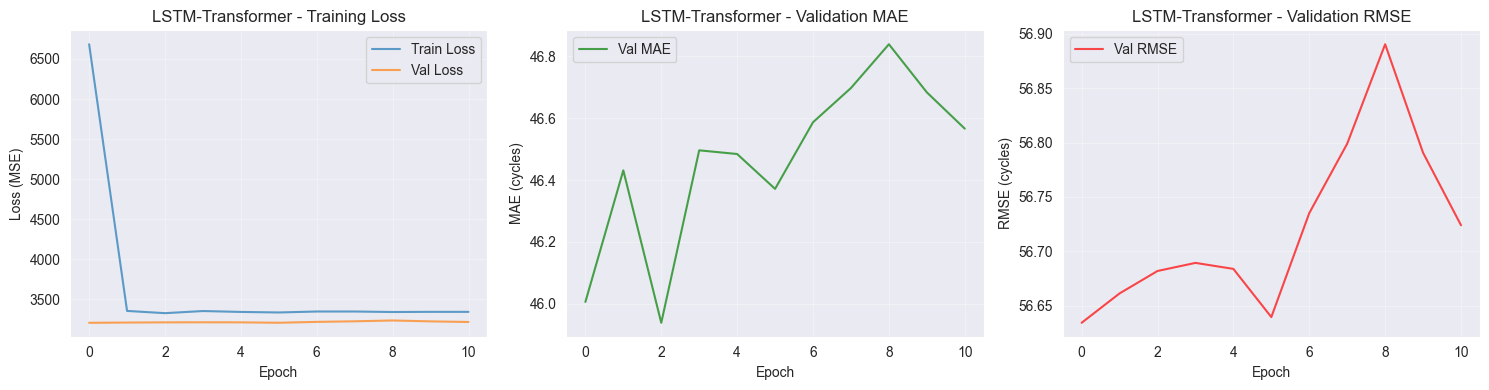

Finished training LSTM-Transformer on Linear RUL (No Norm)

[2/15] Training GRU-Transformer...

Training GRU-Transformer on Linear RUL (No Norm)
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        6129.882354     3210.863585     45.9717      56.6542     
5        3336.987288     3228.073970     46.7108      56.8068     
10       3320.908951     3218.475621     46.5629      56.7221     
15       3329.204725     3237.927515     46.8442      56.8936     

⏹️  Early stopping at epoch 19
✅ Model saved: models/GRU_Transformer_Linear_RUL_No_Norm.pth



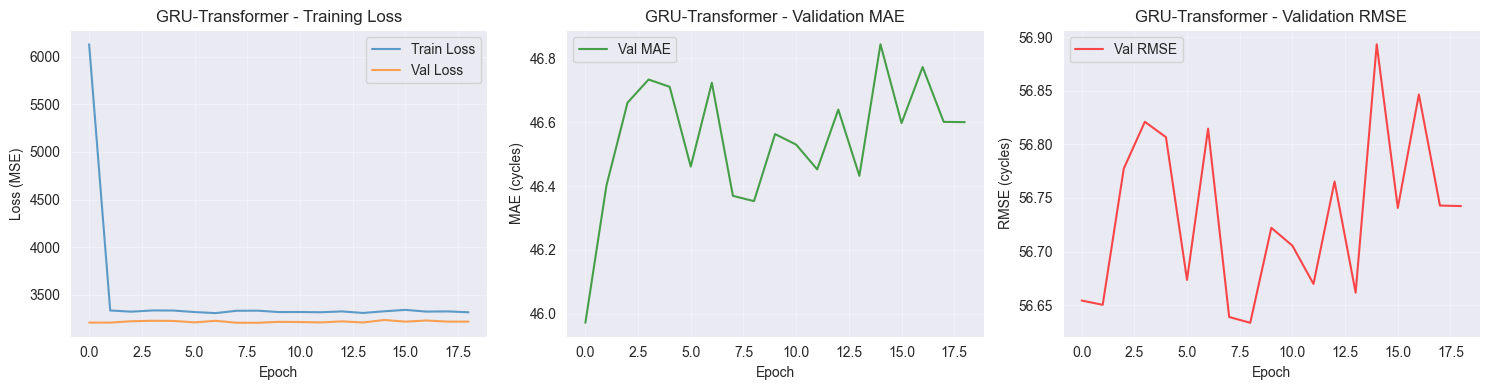

Finished training GRU-Transformer on Linear RUL (No Norm)

[3/15] Training CNN-Transformer...

Training CNN-Transformer on Linear RUL (No Norm)
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        6087.282341     2608.120917     40.5622      51.0621     
5        768.506361      1710.940121     29.4222      41.3598     
10       495.120442      9640.849579     80.3051      98.1760     
15       390.613317      7682.115434     71.6424      87.6370     

⏹️  Early stopping at epoch 19
✅ Model saved: models/CNN_Transformer_Linear_RUL_No_Norm.pth



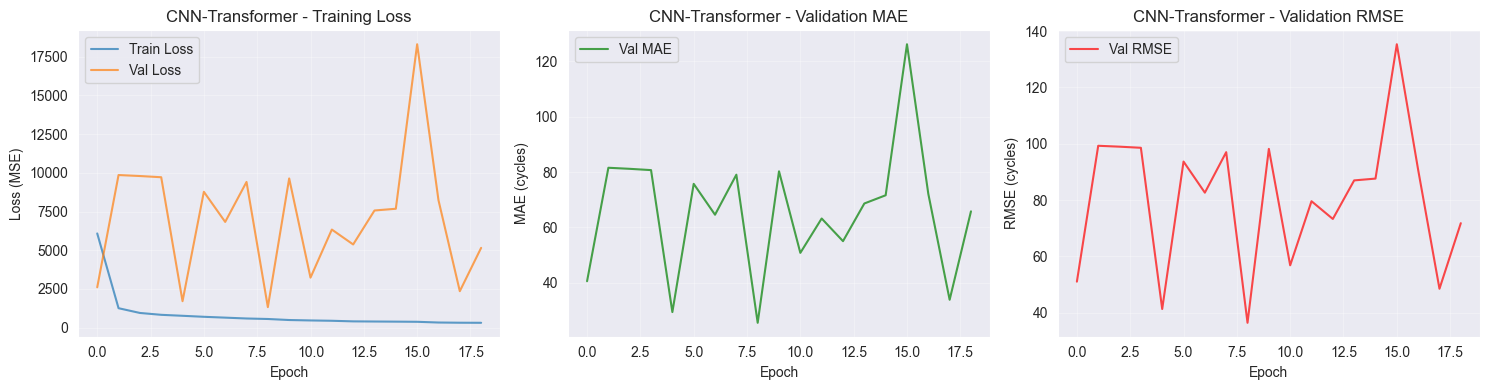

Finished training CNN-Transformer on Linear RUL (No Norm)


████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
DATASET: Linear RUL (Normalized)                                                                                        
████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

[4/15] Training LSTM-Transformer...

Training LSTM-Transformer on Linear RUL (Normalized)
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        6728.899147     2190.674536     33.0398      46.7838     
5        755.278190      678.950699      16.5389      25.8253     
10       648.135384      715.282310      16.7762      26.2407     
15       624.900571      888.790369      20.0372      29.1917     

⏹️  Early stopping at epoch 15
✅ Model saved: models/LSTM_Transformer

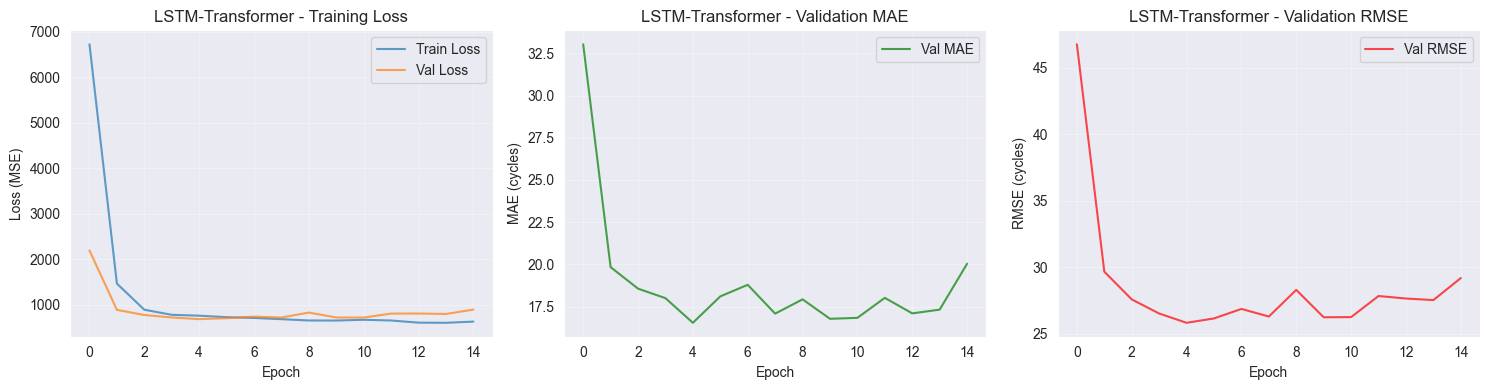

Finished training LSTM-Transformer on Linear RUL (Normalized)

[5/15] Training GRU-Transformer...

Training GRU-Transformer on Linear RUL (Normalized)
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        6614.512357     1793.485401     28.7894      42.3411     
5        683.310530      576.740769      16.3592      24.0181     
10       620.435481      518.149077      14.9888      22.7675     
15       549.937109      520.985171      15.1888      22.8367     
20       503.872412      413.879362      13.3886      20.3471     
25       403.556399      310.051869      12.2190      17.6126     
30       368.703981      291.502235      11.7568      17.0736     
35       246.472071      182.422587      9.5473       13.5137     
40       199.293539      152.083063      8.6237       12.3332     
45       195.910910      140.930410      8.5022       11.8529     
50       132.072092      95.095

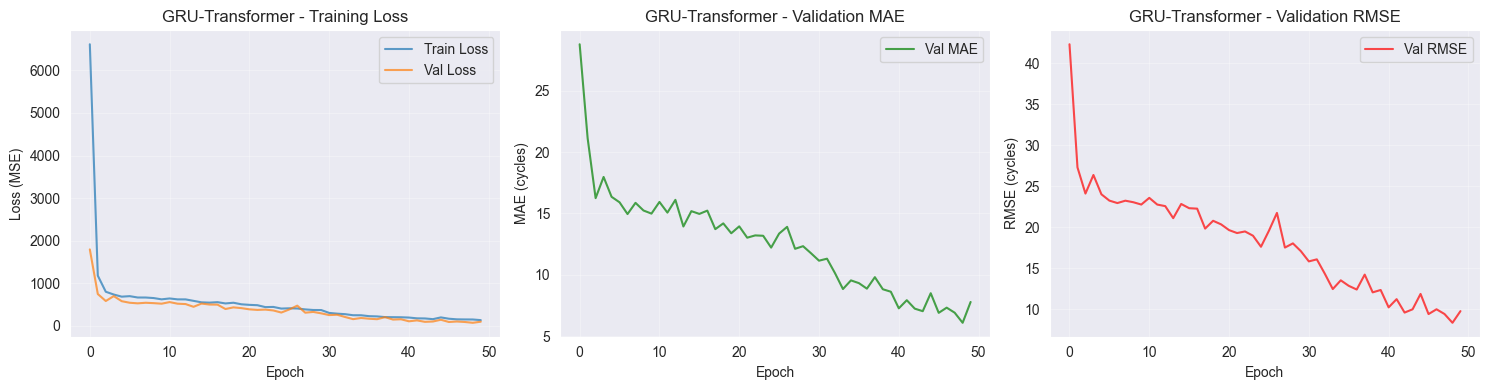

Finished training GRU-Transformer on Linear RUL (Normalized)

[6/15] Training CNN-Transformer...

Training CNN-Transformer on Linear RUL (Normalized)
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        6862.973226     1794.735927     27.1938      42.3555     
5        476.684955      354.145844      14.0983      18.8176     
10       247.680448      133.693721      9.0850       11.5626     
15       178.341879      101.816097      7.4933       10.0886     
20       137.119242      65.809267       6.0089       8.1152      
25       125.028788      53.781552       5.2547       7.3282      
30       119.172802      50.800374       5.3468       7.1289      
35       102.944659      31.902934       4.3335       5.6512      
40       99.686349       35.414151       4.6278       5.9534      
45       94.474318       28.816316       4.0503       5.3697      
50       95.089378       31.4874

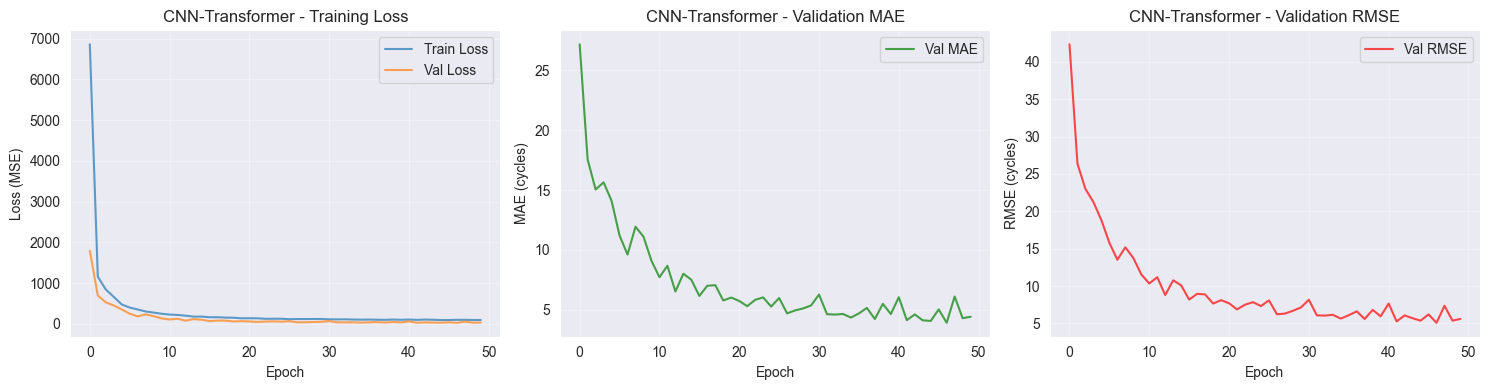

Finished training CNN-Transformer on Linear RUL (Normalized)


████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
DATASET: Piecewise RUL (150)                                                                                            
████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

[7/15] Training LSTM-Transformer...

Training LSTM-Transformer on Piecewise RUL (150)
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        5328.865333     2158.435881     40.0779      46.4485     
5        340.929131      286.230905      12.1434      16.7313     
10       308.159214      290.615121      11.2709      16.8051     
15       296.206102      343.345478      13.3825      18.2811     

⏹️  Early stopping at epoch 15
✅ Model saved: models/LSTM_Transformer_

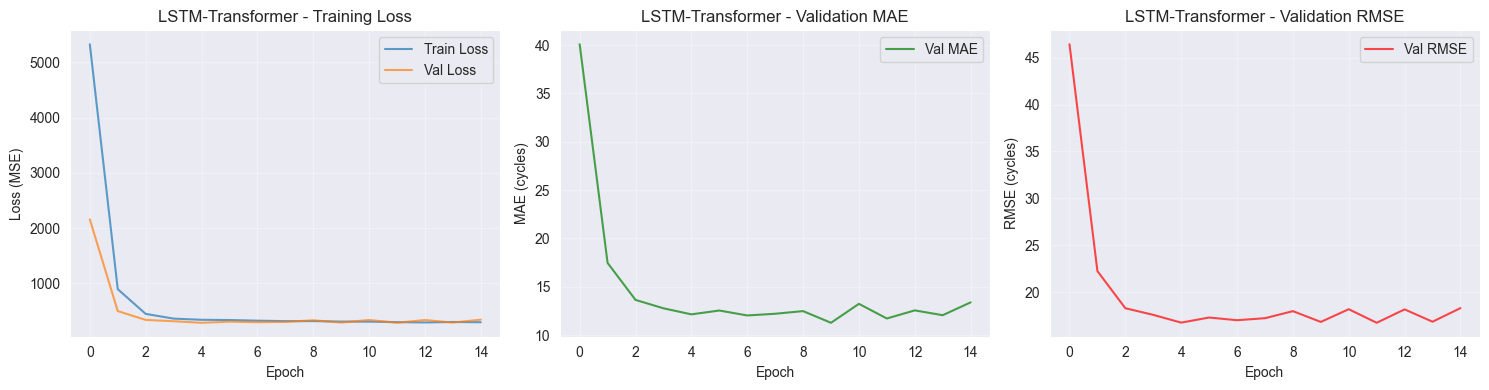

Finished training LSTM-Transformer on Piecewise RUL (150)

[8/15] Training GRU-Transformer...

Training GRU-Transformer on Piecewise RUL (150)
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        5332.770852     1635.787408     31.4634      40.4361     
5        314.453654      252.935226      12.3401      15.9037     
10       294.849961      214.529157      10.6745      14.6447     
15       279.192928      215.834568      10.7158      14.6950     
20       260.987592      199.949630      10.1777      14.1392     
25       227.348812      169.564999      9.1845       13.0201     
30       206.422931      130.359670      8.2534       11.4104     
35       172.430265      91.959141       6.8731       9.5900      
40       147.334071      121.009863      7.7752       11.0033     
45       123.803399      56.111503       5.4357       7.4897      
50       109.369418      40.341857     

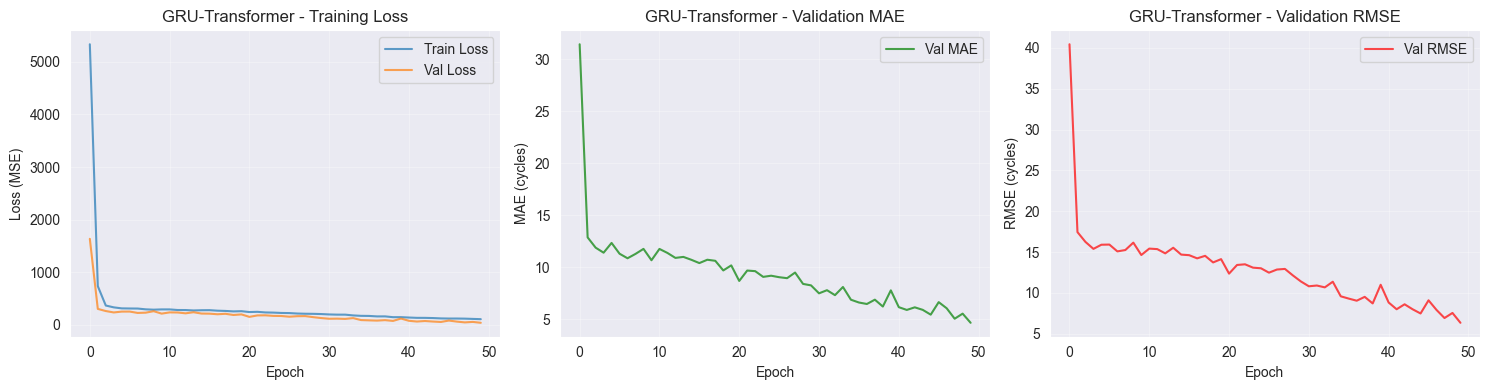

Finished training GRU-Transformer on Piecewise RUL (150)

[9/15] Training CNN-Transformer...

Training CNN-Transformer on Piecewise RUL (150)
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        5021.967702     966.852575      23.5544      31.0898     
5        272.914373      149.239047      9.4814       12.2199     
10       150.448863      79.059894       6.7855       8.8959      
15       123.596824      35.700745       4.5060       5.9749      
20       102.481268      31.698595       4.4028       5.6322      
25       98.779961       27.807628       4.0715       5.2737      
30       90.051617       27.783477       4.2026       5.2726      
35       92.534663       22.484216       3.7513       4.7433      
40       89.898787       22.742655       3.6806       4.7693      

⏹️  Early stopping at epoch 44
✅ Model saved: models/CNN_Transformer_Piecewise_RUL_150.pth



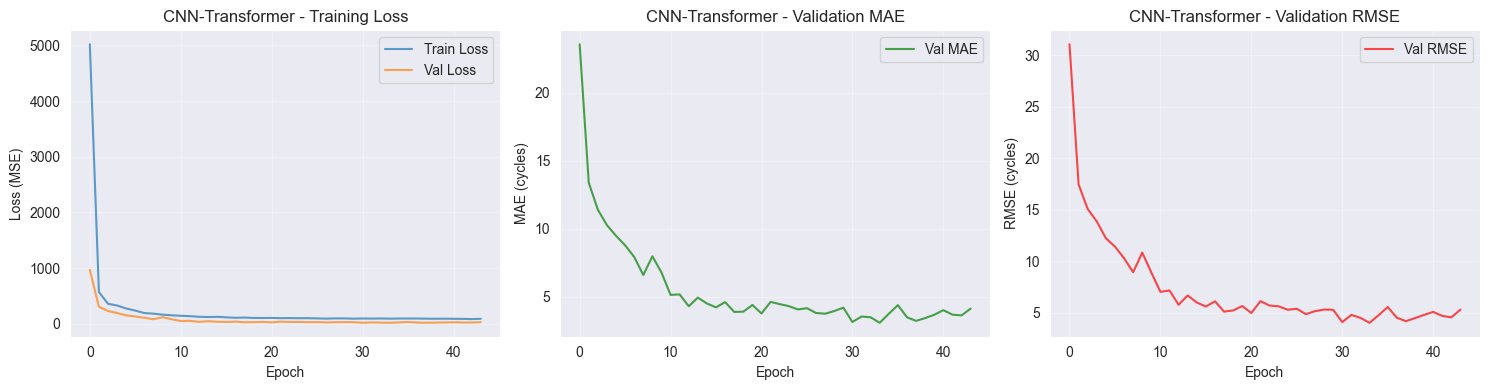

Finished training CNN-Transformer on Piecewise RUL (150)


████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
DATASET: FE - Manual (Corr)                                                                                             
████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

[10/15] Training LSTM-Transformer...

Training LSTM-Transformer on FE - Manual (Corr)
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        4964.787960     1298.996619     28.4118      36.0018     
5        336.893109      343.089653      13.5212      18.2724     
10       307.309012      298.725784      11.7155      17.0267     
15       294.280133      336.796324      11.7041      17.9718     
20       262.536890      314.424905      10.8685      17.2756     

⏹️  Ear

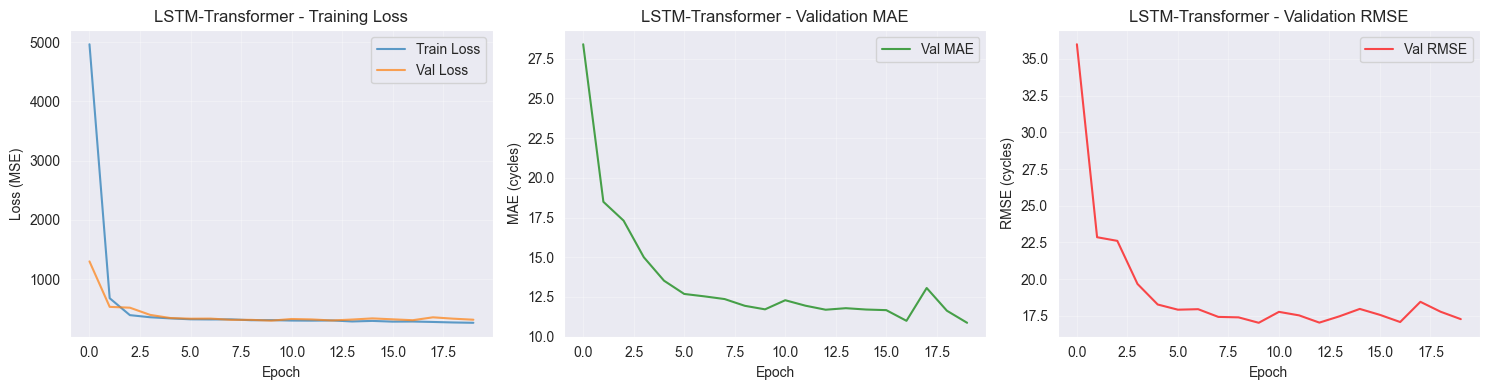

Finished training LSTM-Transformer on FE - Manual (Corr)

[11/15] Training GRU-Transformer...

Training GRU-Transformer on FE - Manual (Corr)
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        4698.725655     925.995645      23.8183      30.4240     
5        302.638657      222.554503      11.0662      14.9203     
10       280.842219      224.374696      10.8660      14.9809     
15       265.309409      215.617774      10.8883      14.6838     
20       269.085267      214.077458      10.7335      14.6313     
25       258.358543      194.451129      10.0602      13.9464     
30       228.737447      185.733795      9.6836       13.6294     
35       196.810605      149.935679      8.8750       12.2383     
40       157.003684      111.597685      7.4757       10.5547     
45       122.260562      76.594900       6.3312       8.7460      
50       100.611537      61.659451      

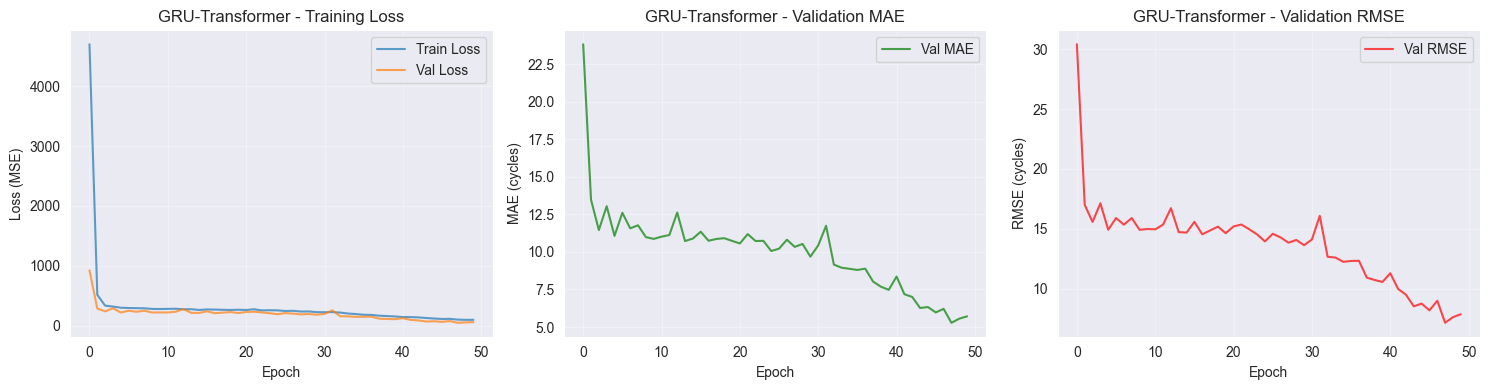

Finished training GRU-Transformer on FE - Manual (Corr)

[12/15] Training CNN-Transformer...

Training CNN-Transformer on FE - Manual (Corr)
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        4553.241505     914.436418      23.1205      30.2399     
5        200.116829      104.095504      7.5155       10.2049     
10       113.897660      76.438425       6.7918       8.7444      
15       91.616341       37.296358       4.4234       6.1074      
20       85.116652       46.857813       5.1630       6.8452      
25       77.699814       28.760635       4.2653       5.3610      
30       75.700102       32.175113       4.3388       5.6741      
35       75.136849       32.508597       4.3098       5.7029      
40       69.164676       29.278040       4.2492       5.4108      

⏹️  Early stopping at epoch 41
✅ Model saved: models/CNN_Transformer_FE_-_Manual_Corr.pth



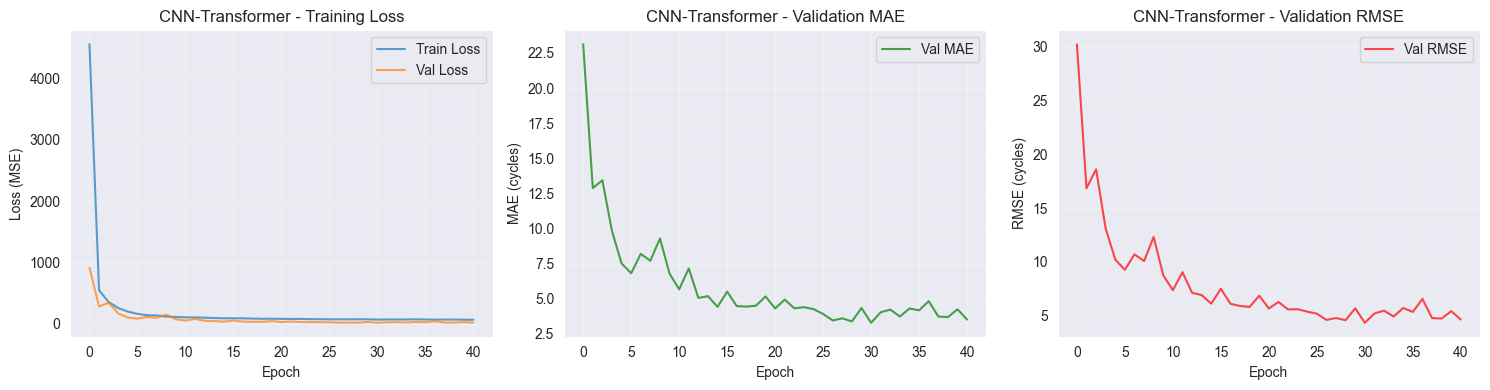

Finished training CNN-Transformer on FE - Manual (Corr)


████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
DATASET: FE - Low Variance                                                                                              
████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

[13/15] Training LSTM-Transformer...

Training LSTM-Transformer on FE - Low Variance
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        5561.935756     2334.165991     41.4186      48.3050     
5        401.947119      287.924406      13.0961      16.9140     
10       328.329409      235.777286      11.0715      15.3021     
15       309.093780      241.941660      11.2919      15.5021     
20       311.258504      237.779670      11.2429      15.3625     
25       3

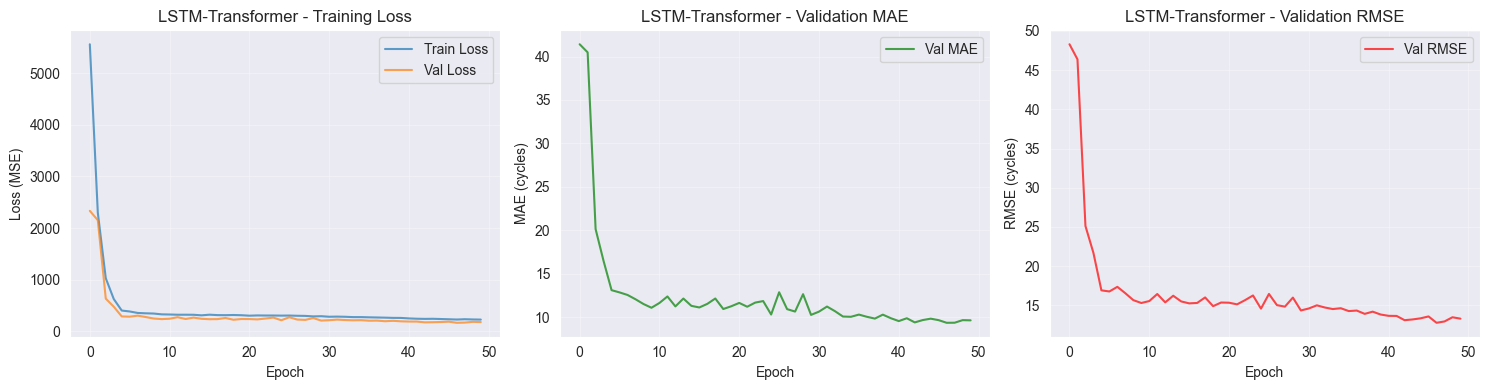

Finished training LSTM-Transformer on FE - Low Variance

[14/15] Training GRU-Transformer...

Training GRU-Transformer on FE - Low Variance
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        4701.907061     972.524373      25.3592      31.1802     
5        291.211056      263.875352      12.9934      16.2455     
10       276.260931      269.187282      12.0936      16.4137     
15       266.903173      225.650972      11.1015      15.0243     
20       247.349690      183.308923      9.4588       13.5392     
25       209.951986      139.189192      8.5422       11.7942     
30       157.179538      103.638477      7.3289       10.1758     
35       128.416588      79.156178       6.5404       8.8964      
40       108.716943      67.824226       6.1151       8.2318      
45       94.806376       66.273144       6.2575       8.1361      
50       85.526460       34.207968       4

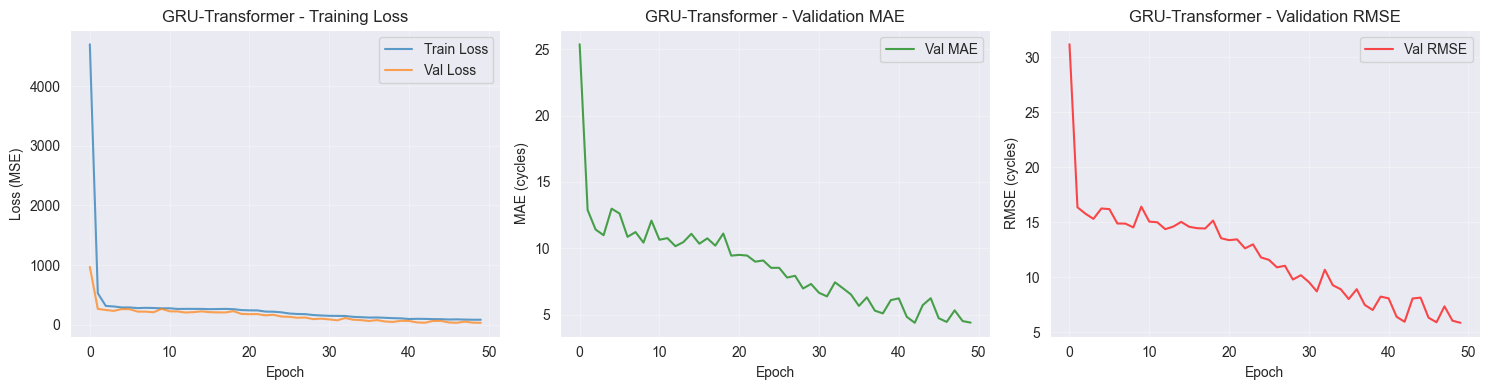

Finished training GRU-Transformer on FE - Low Variance

[15/15] Training CNN-Transformer...

Training CNN-Transformer on FE - Low Variance
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        4330.133283     665.517724      20.3700      25.7931     
5        205.188899      158.768793      8.9670       12.6002     
10       111.470360      62.721651       5.9463       7.9207      
15       95.077251       39.422004       4.6494       6.2785      
20       85.027161       28.029745       3.9611       5.2927      
25       81.024760       40.760760       4.8693       6.3843      
30       74.688158       24.527757       3.7419       4.9540      
35       70.031396       28.732089       4.2160       5.3611      

⏹️  Early stopping at epoch 38
✅ Model saved: models/CNN_Transformer_FE_-_Low_Variance.pth



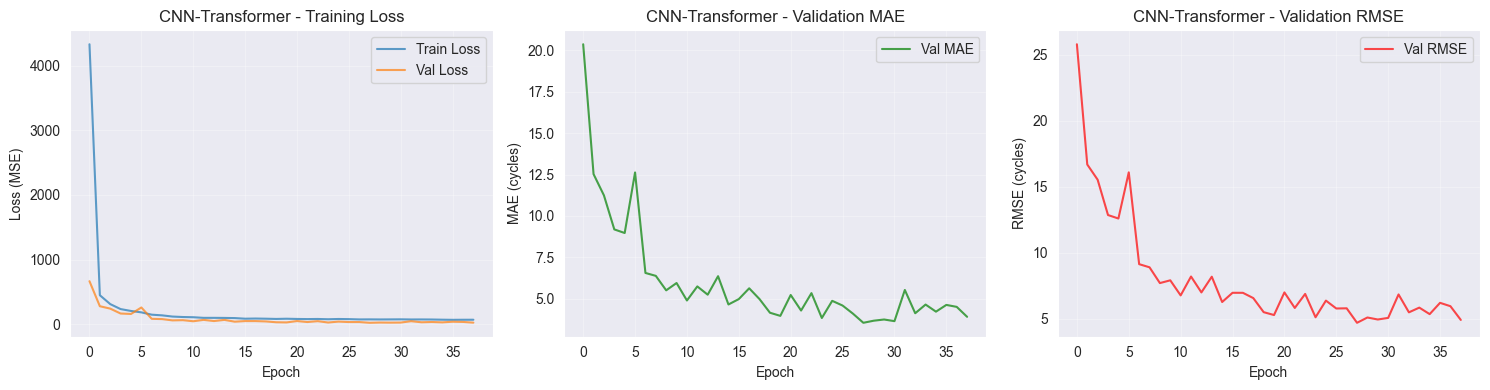

Finished training CNN-Transformer on FE - Low Variance



In [ ]:
# ============ TRAIN ALL 3 MODELS ON ALL 5 DATASETS ============

print("\n" + "="*120)
print("COMPREHENSIVE MODEL TRAINING: 3 Models × 5 Datasets = 15 Training Runs".center(120))
print("="*120)

# Get dataset names and model names from existing structures
dataset_names = list(datasets_config.keys())
model_names_list = ['LSTM-Transformer', 'GRU-Transformer', 'CNN-Transformer']

# Helper to get feature count for each dataset
get_num_features = lambda dataset_name: len([col for col in datasets_config[dataset_name][0].columns 
                                            if col[0] == 's' and col[1:].isdigit()])

# Model factory functions
models_config_dict = {
    'LSTM-Transformer': lambda nf: LSTMTransformer(num_features=nf, 
                                                lstm_hidden=64, 
                                                num_lstm_layers=2,
                                                d_model=64, 
                                                nhead=4, 
                                                num_transformer_layers=2, 
                                                dropout=0.1),
    'GRU-Transformer': lambda nf: GRUTransformer(num_features=nf, 
                                                gru_hidden=64, 
                                                num_gru_layers=2,
                                                d_model=64,
                                                nhead=4, 
                                                num_transformer_layers=2, 
                                                dropout=0.1),
    'CNN-Transformer': lambda nf: CNNTransformer(num_features=nf, 
                                                num_filters=32, 
                                                kernel_size=3,
                                                d_model=64, 
                                                nhead=4, 
                                                num_transformer_layers=2, 
                                                dropout=0.1)
}


trained_models_all = {}
training_results_all = {}

total_runs = len(dataset_names) * len(model_names_list)
current_run = 0

for dataset_name in dataset_names:
    print(f"\n{'█'*120}")
    print(f"DATASET: {dataset_name}".ljust(120))
    print(f"{'█'*120}\n")
    
    # Get loaders and feature count for this dataset
    train_loader_current = train_loaders[dataset_name]
    val_loader_current = val_loaders[dataset_name]
    num_features = get_num_features(dataset_name)
    
    for model_name in model_names_list:
        current_run += 1
        print(f"[{current_run}/{total_runs}] Training {model_name}...")
        
        # Create fresh model instance for this dataset
        model = models_config_dict[model_name](num_features)
        trainer = ModelTrainer(model, DEVICE, f"{model_name}", dataset_name=dataset_name, 
                                models_dir='models', logs_dir='logs')
        history = trainer.train(
            train_loader_current, 
            val_loader_current, 
            epochs=50, 
            lr=0.001, 
            early_stopping_patience=10
        )
        
        key = (dataset_name, model_name)
        trained_models_all[key] = model
        training_results_all[key] = history

        # Plot training history for this run
        trainer.plot_history()
        print(f"Finished training {model_name} on {dataset_name}\n")

In [53]:
# ============ EVALUATE ALL MODELS ON ALL TEST SETS ============

def phm08_scoring_function(y_pred, y_true):
    """
    PHM08 Competition Scoring Function
    Asymmetric cost function: penalizes early predictions more than late ones
    
    Score = sum(exp(-d_i/13) - 1) if d_i < 0 (over-estimate: early prediction)
        = sum(exp(d_i/10) - 1) if d_i >= 0 (under-estimate: late prediction)
    
    where d_i = y_pred_i - y_true_i
    """
    errors = y_pred - y_true
    score = 0
    
    for error in errors:
        if error < 0:  # Over-estimate (predicted fewer cycles remaining)
            score += np.exp(-error / 13) - 1
        else:  # Under-estimate (predicted more cycles remaining)
            score += np.exp(error / 10) - 1
    
    return score

def weighted_rul_error(y_pred, y_true):
    """
    Weighted RUL Error - penalizes late stage failures more
    """
    errors = np.abs(y_pred - y_true)
    weights = 1 + (y_true / y_true.max())  # Higher weight for higher RUL values
    weighted_error = np.mean(errors * weights)
    return weighted_error

def evaluate_model(model, test_loader, device, model_name):
    """Evaluate model on test set and return predictions and metrics"""
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            predictions = model(X_batch)
            all_preds.extend(predictions.cpu().numpy())
            all_targets.extend(y_batch.numpy())
    
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    mae = mean_absolute_error(all_targets, all_preds)
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    r2 = r2_score(all_targets, all_preds)
    weighted_error = weighted_rul_error(all_preds, all_targets)
    phm08_score = phm08_scoring_function(all_preds, all_targets)
    
    return {
        'predictions': all_preds,
        'targets': all_targets,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'weighted_error': weighted_error,
        'phm08_score': phm08_score
    }

def load_model_from_disk(model_name, dataset_name, num_features, device, models_dir='models'):
    """
    Load model from disk and return model instance.
    
    Args:
        model_name: Model architecture name (LSTM-Transformer, GRU-Transformer, CNN-Transformer)
        dataset_name: Dataset name (used to find the saved file)
        num_features: Number of input features
        device: Device to load model to
        models_dir: Directory where models are saved
    
    Returns:
        model: Loaded model on device, or None if not found
    """
    import os
    from pathlib import Path
    
    # Build filename from model and dataset names
    safe_model_name = model_name.replace('-', '_')
    safe_dataset_name = dataset_name.replace(' ', '_').replace('(', '').replace(')', '')
    model_filename = f"{safe_model_name}_{safe_dataset_name}.pth"
    model_path = os.path.join(models_dir, model_filename)
    
    # Check if file exists
    if not os.path.exists(model_path):
        print(f"   ❌ Model file not found: {model_path}")
        return None
    
    try:
        # Create model instance
        if 'LSTM' in model_name:
            model = LSTMTransformer(
                num_features=num_features,
                lstm_hidden=64,
                num_lstm_layers=2,
                d_model=64,
                nhead=4,
                num_transformer_layers=2,
                dropout=0.1
            )
        elif 'GRU' in model_name:
            model = GRUTransformer(
                num_features=num_features,
                gru_hidden=64,
                num_gru_layers=2,
                d_model=64,
                nhead=4,
                num_transformer_layers=2,
                dropout=0.1
            )
        elif 'CNN' in model_name:
            model = CNNTransformer(
                num_features=num_features,
                num_filters=32,
                kernel_size=3,
                d_model=64,
                nhead=4,
                num_transformer_layers=2,
                dropout=0.1
            )
        else:
            print(f"   ❌ Unknown model type: {model_name}")
            return None
        
        # Load weights from disk
        model.load_state_dict(torch.load(model_path, map_location=device))
        model = model.to(device)
        model.eval()
        
        print(f"   ✅ Loaded: {model_filename}")
        return model
    
    except Exception as e:
        print(f"   ❌ Error loading model: {e}")
        return None

# ============ EVALUATE ALL MODELS ON ALL TEST SETS (LOAD FROM DISK) ============

print("\n" + "="*140)
print("LOADING MODELS FROM DISK & EVALUATING ON TEST SETS".center(140))
print("="*140)

test_results_all = {}

for dataset_name in dataset_names:
    print(f"\n📂 Dataset: {dataset_name}")
    test_loader_current = test_loaders[dataset_name]
    num_features = get_num_features(dataset_name)
    
    for model_name in model_names_list:
        key = (dataset_name, model_name)
        
        # Load model from disk
        model = load_model_from_disk(model_name, dataset_name, num_features, DEVICE, models_dir='models')
        
        if model is None:
            print(f"⚠️  Skipping {model_name} on {dataset_name} - model file not found")
            continue
        
        # Evaluate model
        results = evaluate_model(model, test_loader_current, DEVICE, f"{model_name} on {dataset_name}")
        test_results_all[key] = results
        print(f"   Results: MAE={results['mae']:.4f}, RMSE={results['rmse']:.4f}, R²={results['r2']:.4f}")

# ============ COMPILE RESULTS IN MINIMAL TABLE FORMAT ============

print("\n" + "="*140)
print("RESULTS SUMMARY: All Models on All Datasets (Minimal Format)".center(140))
print("="*140)

# Compile results into a flat DataFrame
results_data = []
for dataset_name in dataset_names:
    for model_name in model_names_list:
        key = (dataset_name, model_name)
        
        # Skip if results don't exist (model wasn't trained)
        if key not in test_results_all:
            continue
        
        results = test_results_all[key]
        
        results_data.append({
            'Dataset': dataset_name,
            'Model': model_name,
            'MAE': f"{results['mae']:.4f}",
            'RMSE': f"{results['rmse']:.4f}",
            'R²': f"{results['r2']:.4f}",
            'PHM08': f"{results['phm08_score']:.2f}"
        })

results_df = pd.DataFrame(results_data)
print("\n" + results_df.to_string(index=False))
print("\n" + "="*140)

# Find best model for each dataset
print("\nBEST MODELS BY DATASET (Lowest RMSE):\n")
for dataset_name in dataset_names:
    best_model = None
    best_rmse = float('inf')
    
    for model_name in model_names_list:
        key = (dataset_name, model_name)
        
        # Skip if model wasn't evaluated
        if key not in test_results_all:
            continue
        
        rmse = test_results_all[key]['rmse']
        if rmse < best_rmse:
            best_rmse = rmse
            best_model = model_name
    
    if best_model:
        print(f"  {dataset_name:<25} → {best_model:<20} (RMSE: {best_rmse:.4f})")
    else:
        print(f"  {dataset_name:<25} → No models evaluated")

# Overall best model across all datasets
print("\nOVERALL BEST MODEL (Avg RMSE across all datasets):\n")
model_avg_rmse = {}
for model_name in model_names_list:
    rmse_list = []
    for dataset_name in dataset_names:
        key = (dataset_name, model_name)
        
        # Skip if model wasn't evaluated
        if key not in test_results_all:
            continue
        
        rmse_list.append(test_results_all[key]['rmse'])
    
    # Only add to average if at least one evaluation exists
    if rmse_list:
        model_avg_rmse[model_name] = np.mean(rmse_list)

if model_avg_rmse:
    best_overall = min(model_avg_rmse, key=model_avg_rmse.get)
    for model_name, avg_rmse in sorted(model_avg_rmse.items(), key=lambda x: x[1]):
        print(f"  {model_name:<20} - Avg RMSE: {avg_rmse:.4f}")
    print(f"\nWinner: {best_overall}\n")
else:
    print("No models evaluated successfully.")

print("="*140)


                                             LOADING MODELS FROM DISK & EVALUATING ON TEST SETS                                             

📂 Dataset: Linear RUL (No Norm)
   ✅ Loaded: LSTM_Transformer_Linear_RUL_No_Norm.pth
   Results: MAE=47.7646, RMSE=60.2257, R²=-0.3365
   ✅ Loaded: GRU_Transformer_Linear_RUL_No_Norm.pth
   Results: MAE=47.6510, RMSE=60.0903, R²=-0.3305
   ✅ Loaded: CNN_Transformer_Linear_RUL_No_Norm.pth
   Results: MAE=51.5659, RMSE=59.5544, R²=-0.3069

📂 Dataset: Linear RUL (Normalized)
   ✅ Loaded: LSTM_Transformer_Linear_RUL_Normalized.pth
   Results: MAE=26.0101, RMSE=35.0321, R²=0.5478
   ✅ Loaded: GRU_Transformer_Linear_RUL_Normalized.pth
   Results: MAE=27.4006, RMSE=38.0688, R²=0.4660
   ✅ Loaded: CNN_Transformer_Linear_RUL_Normalized.pth
   Results: MAE=27.5253, RMSE=37.8594, R²=0.4719

📂 Dataset: Piecewise RUL (150)
   ✅ Loaded: LSTM_Transformer_Piecewise_RUL_150.pth
   Results: MAE=14.9395, RMSE=19.6574, R²=0.7464
   ✅ Loaded: GRU_Transformer_Piecewi

✅ Found 3 available models and 5 available datasets
   Models: LSTM-Transformer, GRU-Transformer, CNN-Transformer
   Datasets: Linear RUL (No Norm), Linear RUL (Normalized), Piecewise RUL (150), FE - Manual (Corr), FE - Low Variance


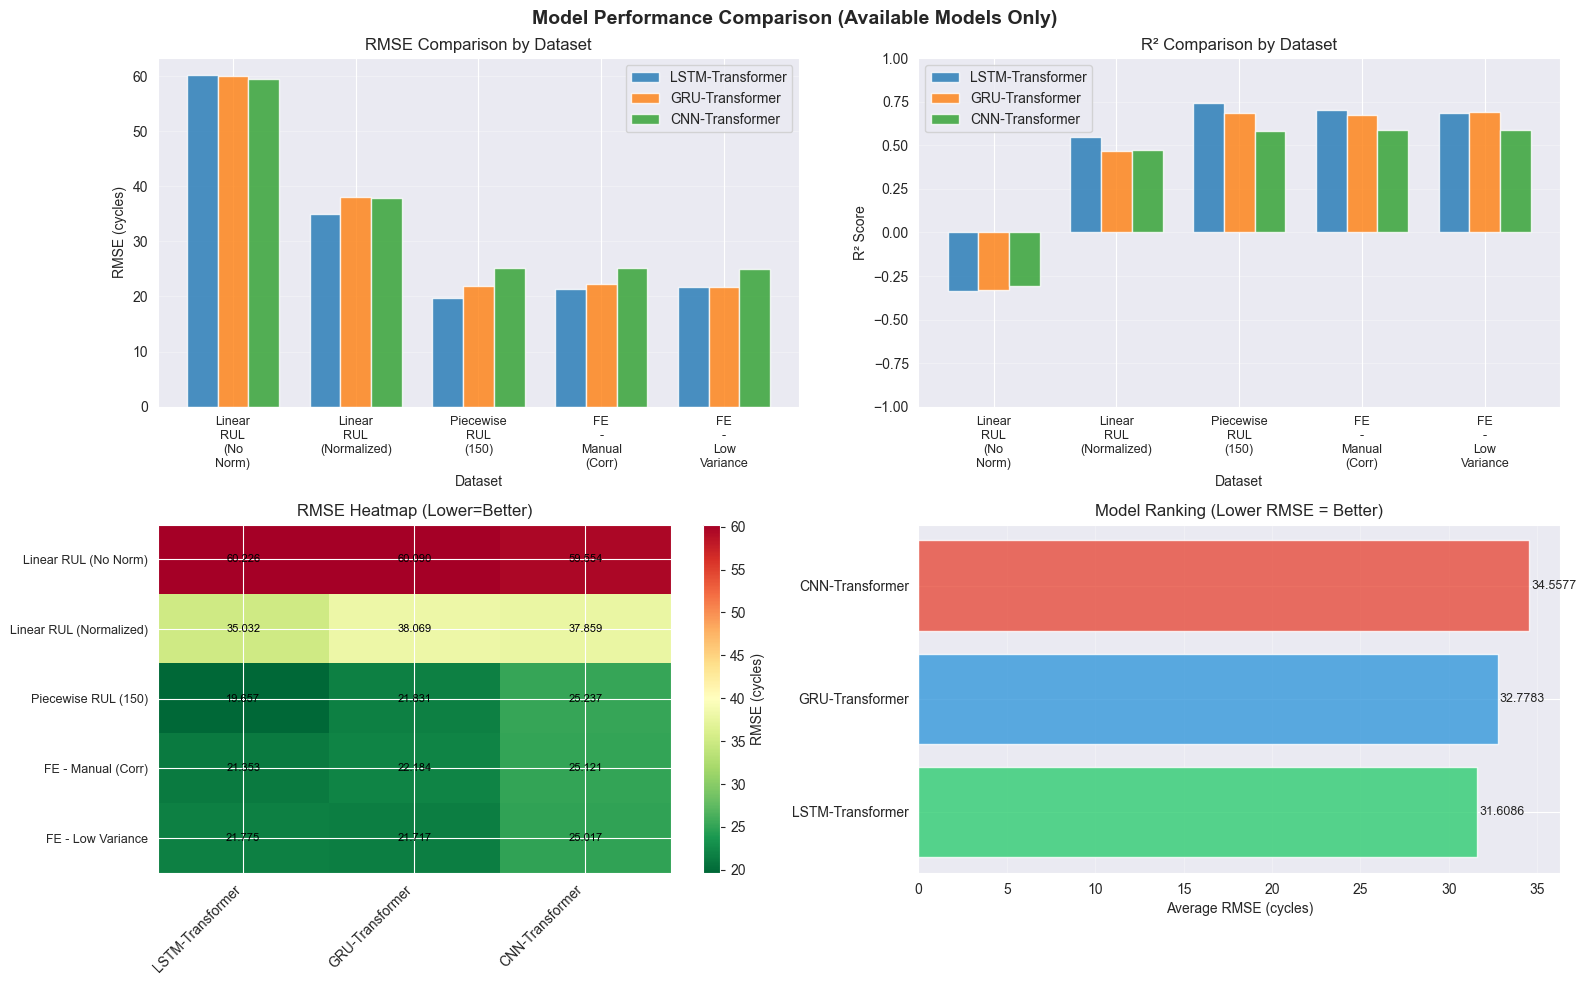

In [56]:
# ============ VISUALIZATION: MINIMAL COMPARISON PLOTS (WITH FAILSAFE) ============

def build_evaluation_data(test_results_all, dataset_names, model_names_list):
    """
    Safely build evaluation data, only including models that were successfully evaluated.
    Returns available datasets and models, plus their metrics.
    """
    # Find available models and datasets from actual results
    available_models = set()
    available_datasets = set()
    
    for (dataset_name, model_name) in test_results_all.keys():
        available_models.add(model_name)
        available_datasets.add(dataset_name)
    
    # Filter to use only available combinations
    available_models = [m for m in model_names_list if m in available_models]
    available_datasets = [d for d in dataset_names if d in available_datasets]
    
    if not available_models or not available_datasets:
        print("⚠️  No successful model evaluations found!")
        return None
    
    print(f"✅ Found {len(available_models)} available models and {len(available_datasets)} available datasets")
    print(f"   Models: {', '.join(available_models)}")
    print(f"   Datasets: {', '.join(available_datasets)}")
    
    # Build metrics dictionaries only for available combinations
    rmse_by_model_dataset = {}
    r2_by_model_dataset = {}
    
    for model_name in available_models:
        rmse_by_model_dataset[model_name] = []
        r2_by_model_dataset[model_name] = []
        
        for dataset_name in available_datasets:
            key = (dataset_name, model_name)
            
            # Only add if this combination exists
            if key in test_results_all:
                rmse_by_model_dataset[model_name].append(test_results_all[key]['rmse'])
                r2_by_model_dataset[model_name].append(test_results_all[key]['r2'])
            else:
                # Skip missing combinations (will be shown as gaps)
                pass
    
    return {
        'rmse_by_model_dataset': rmse_by_model_dataset,
        'r2_by_model_dataset': r2_by_model_dataset,
        'available_models': available_models,
        'available_datasets': available_datasets
    }

# ============ BUILD AND VALIDATE EVALUATION DATA ============

eval_data = build_evaluation_data(test_results_all, dataset_names, model_names_list)

if eval_data is None:
    print("\n❌ Cannot create visualization - no successful model evaluations")
else:
    # Extract data
    rmse_by_model_dataset = eval_data['rmse_by_model_dataset']
    r2_by_model_dataset = eval_data['r2_by_model_dataset']
    available_models = eval_data['available_models']
    available_datasets = eval_data['available_datasets']
    
    # Create compact 2x2 comparison plots
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Model Performance Comparison (Available Models Only)', fontsize=14, fontweight='bold')
    
    # 1. RMSE comparison - grouped by model
    x = np.arange(len(available_datasets))
    width = 0.25 if len(available_models) > 1 else 0.4
    
    for idx, model_name in enumerate(available_models):
        axes[0, 0].bar(x + idx*width, rmse_by_model_dataset[model_name], width, label=model_name, alpha=0.8)
    
    axes[0, 0].set_xlabel('Dataset')
    axes[0, 0].set_ylabel('RMSE (cycles)')
    axes[0, 0].set_title('RMSE Comparison by Dataset')
    axes[0, 0].set_xticks(x + width * (len(available_models) - 1) / 2)
    axes[0, 0].set_xticklabels([d.replace(' ', '\n') for d in available_datasets], fontsize=9)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # 2. R² comparison - grouped by model
    for idx, model_name in enumerate(available_models):
        axes[0, 1].bar(x + idx*width, r2_by_model_dataset[model_name], width, label=model_name, alpha=0.8)
    
    axes[0, 1].set_xlabel('Dataset')
    axes[0, 1].set_ylabel('R² Score')
    axes[0, 1].set_title('R² Comparison by Dataset')
    axes[0, 1].set_xticks(x + width * (len(available_models) - 1) / 2)
    axes[0, 1].set_xticklabels([d.replace(' ', '\n') for d in available_datasets], fontsize=9)
    axes[0, 1].set_ylim([-1, 1])
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # 3. RMSE heatmap
    rmse_matrix = np.array([[rmse_by_model_dataset[m][i] for m in available_models] for i in range(len(available_datasets))])
    im = axes[1, 0].imshow(rmse_matrix, cmap='RdYlGn_r', aspect='auto')
    axes[1, 0].set_xticks(np.arange(len(available_models)))
    axes[1, 0].set_yticks(np.arange(len(available_datasets)))
    axes[1, 0].set_xticklabels(available_models, rotation=45, ha='right')
    axes[1, 0].set_yticklabels(available_datasets, fontsize=9)
    axes[1, 0].set_title('RMSE Heatmap (Lower=Better)')
    
    # Add values to heatmap
    for i in range(len(available_datasets)):
        for j in range(len(available_models)):
            text = axes[1, 0].text(j, i, f'{rmse_matrix[i, j]:.3f}',
                                    ha="center", va="center", color="black", fontsize=8)
    
    plt.colorbar(im, ax=axes[1, 0], label='RMSE (cycles)')
    
    # 4. Model performance ranking
    model_avg_rmse = {}
    for model_name in available_models:
        rmse_list = [test_results_all[(dataset_name, model_name)]['rmse'] 
                     for dataset_name in available_datasets 
                     if (dataset_name, model_name) in test_results_all]
        
        if rmse_list:  # Only include if has results
            model_avg_rmse[model_name] = np.mean(rmse_list)
    
    if model_avg_rmse:
        sorted_models = sorted(model_avg_rmse.items(), key=lambda x: x[1])
        model_names_sorted = [m[0] for m in sorted_models]
        rmse_sorted = [m[1] for m in sorted_models]
        colors_rank = ['#2ecc71', '#3498db', '#e74c3c'][:len(sorted_models)]
        
        axes[1, 1].barh(model_names_sorted, rmse_sorted, color=colors_rank, alpha=0.8)
        axes[1, 1].set_xlabel('Average RMSE (cycles)')
        axes[1, 1].set_title('Model Ranking (Lower RMSE = Better)')
        axes[1, 1].grid(True, alpha=0.3, axis='x')
        
        for i, v in enumerate(rmse_sorted):
            axes[1, 1].text(v + 0.1, i, f'{v:.4f}', va='center', fontsize=9)
    else:
        axes[1, 1].text(0.5, 0.5, 'No ranking data available', ha='center', va='center')
        axes[1, 1].set_title('Model Ranking')
    
    plt.tight_layout()
    plt.show()
    

# FD002 Dataset Exploration & Training

### FD002 has More Complex Operating Conditions (6 different condition combinations)

**Comparison:**
- **FD001:** 3 operating conditions (simpler degradation pattern)
- **FD002:** 6 operating conditions (more complex degradation pattern)


## Part 1: Dataset Exploration for FD002

In [ ]:
# train_df_fd002 = pd.read_csv('../data/processed-nasa-data/train_processed_rul_only_fd002.csv')
# test_df_fd002 = pd.read_csv('../data/processed-nasa-data/test_processed_rul_only_fd002.csv')

# Google Drive (if running in Colab)
DATA_PATH = '/content/drive/My Drive/deep_learning/project/'
train_df_fd002 = pd.read_csv(f'{DATA_PATH}train_processed_rul_only_fd002.csv')
test_df_fd002 = pd.read_csv(f'{DATA_PATH}test_processed_rul_only_fd002.csv')

print("\n" + "="*100)
print("DATASET COMPARISON: FD001 vs FD002")
print("="*100)

comparison_df_datasets = pd.DataFrame({
    'Metric': ['Training Rows', 'Test Rows', 'Total Rows', 'Train Engines', 'Test Engines', 
               'Train RUL Min', 'Train RUL Max', 'Train RUL Mean', 'Num Sensors', 'Operating Conditions'],
    'FD001': [
        f"{train_df.shape[0]:,}",
        f"{test_df.shape[0]:,}",
        f"{train_df.shape[0] + test_df.shape[0]:,}",
        f"{train_df['id'].nunique()}",
        f"{test_df['id'].nunique()}",
        f"{train_df['RUL'].min()}",
        f"{train_df['RUL'].max()}",
        f"{train_df['RUL'].mean():.2f}",
        f"{len([c for c in train_df.columns if c.startswith('s')])}",
        "3 conditions (simple)"
    ],
    'FD002': [
        f"{train_df_fd002.shape[0]:,}",
        f"{test_df_fd002.shape[0]:,}",
        f"{train_df_fd002.shape[0] + test_df_fd002.shape[0]:,}",
        f"{train_df_fd002['id'].nunique()}",
        f"{test_df_fd002['id'].nunique()}",
        f"{train_df_fd002['RUL'].min()}",
        f"{train_df_fd002['RUL'].max()}",
        f"{train_df_fd002['RUL'].mean():.2f}",
        f"{len([c for c in train_df_fd002.columns if c.startswith('s')])}",
        "6 conditions (complex)"
    ]
})

print("\n" + comparison_df_datasets.to_string(index=False))
print("="*100)

print("\nFD002 EDA - Detailed Analysis:")
print(f"\n  Training: {train_df_fd002.shape[0]:,} rows × {train_df_fd002.shape[1]} columns")
print(f"  Test:     {test_df_fd002.shape[0]:,} rows × {test_df_fd002.shape[1]} columns")
print(f"  Engines:  Train={train_df_fd002['id'].nunique()}, Test={test_df_fd002['id'].nunique()}")
print(f"  RUL Range: Train [{train_df_fd002['RUL'].min()}, {train_df_fd002['RUL'].max()}], Std={train_df_fd002['RUL'].std():.2f}")
print(f"  RUL Range: Test [{test_df_fd002['RUL'].min()}, {test_df_fd002['RUL'].max()}], Std={test_df_fd002['RUL'].std():.2f}")

train_cycles_fd002 = train_df_fd002.groupby('id')['cycle'].max()
test_cycles_fd002 = test_df_fd002.groupby('id')['cycle'].max()
print(f"  Cycles per engine: Train [{train_cycles_fd002.min()}, {train_cycles_fd002.max()}], Avg={train_cycles_fd002.mean():.1f}")
print(f"  Cycles per engine: Test [{test_cycles_fd002.min()}, {test_cycles_fd002.max()}], Avg={test_cycles_fd002.mean():.1f}")



DATASET COMPARISON: FD001 vs FD002

              Metric                 FD001                  FD002
       Training Rows                20,631                 53,759
           Test Rows                13,096                 33,991
          Total Rows                33,727                 87,750
       Train Engines                   100                    260
        Test Engines                   100                    259
       Train RUL Min                     0                      0
       Train RUL Max                   361                    377
      Train RUL Mean                107.81                 108.15
         Num Sensors                    24                     24
Operating Conditions 3 conditions (simple) 6 conditions (complex)

FD002 EDA - Detailed Analysis:

  Training: 53,759 rows × 28 columns
  Test:     33,991 rows × 28 columns
  Engines:  Train=260, Test=259
  RUL Range: Train [0, 377], Std=69.18
  RUL Range: Test [6, 377], Std=63.87
  Cycles per engine: 

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. RUL Distribution
''' 
- The RUL distribution in the training set is right-skewed, with most samples having a high RUL (indicating healthy engines) and fewer samples with low RUL (indicating engines close to failure).
- The test set has a similar distribution but with a slightly higher mean RUL, suggesting that the test engines may be generally healthier than those in the training set.
'''
axes[0, 0].hist(train_df_fd002['RUL'], bins=50, alpha=0.7, color='blue', label='Train')
axes[0, 0].hist(test_df_fd002['RUL'], bins=50, alpha=0.7, color='orange', label='Test')
axes[0, 0].set_xlabel('RUL (cycles)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('RUL Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Cycles per Engine
''' 
- The number of cycles per engine varies, with some engines running for over 200 cycles before failure.
- The distribution of cycles per engine is right-skewed, with many engines failing after fewer cycles and a long tail of engines that run for many cycles before failure.
'''
train_cycles_dist = train_df_fd002.groupby('id')['cycle'].max()
axes[0, 1].hist(train_cycles_dist, bins=20, color='green', alpha=0.7)
axes[0, 1].set_xlabel('Cycles per Engine')
axes[0, 1].set_ylabel('Number of Engines')
axes[0, 1].set_title('Training: Cycles per Engine Distribution')
axes[0, 1].grid(True, alpha=0.3)

# 3. Sample sensor trends (Engine 1)
''' 
- The sensor values for Engine 1 show varying patterns over time, with some sensors exhibiting more noise than others.
- There are noticeable trends in the sensor data that may be indicative of engine degradation. For example, sensor s1 shows a gradual increase in values as the engine approaches failure, while sensor s10 exhibits more erratic behavior.
'''
engine1_data = train_df_fd002[train_df_fd002['id'] == 1].sort_values('cycle')
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s1'], label='s1', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s2'], label='s2', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s3'], label='s3', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s10'], label='s10', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s15'], label='s15', alpha=0.7)
axes[1, 0].set_xlabel('Cycle')
axes[1, 0].set_ylabel('Normalized Sensor Value')
axes[1, 0].set_title('Engine 1: Sample Sensor Trends (s1, s2, s3, s10, s15)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. RUL Decay Pattern (Engine 1)
axes[1, 1].plot(engine1_data['cycle'], engine1_data['RUL'], color='red', linewidth=2)
axes[1, 1].set_xlabel('Cycle')
axes[1, 1].set_ylabel('RUL (cycles)')
axes[1, 1].set_title('Engine 1: RUL Over Time (Monotonically Decreasing)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 2: Data Preparation & Sequence Creation for FD002

In [ ]:
train_dataset_fd002 = RULDataset(train_df_fd002, SEQUENCE_LENGTH, feature_cols)
test_dataset_fd002 = RULDataset(test_df_fd002, SEQUENCE_LENGTH, feature_cols)

train_size_fd002 = int(TRAIN_TEST_SPLIT * len(train_dataset_fd002))
val_size_fd002 = len(train_dataset_fd002) - train_size_fd002
train_dataset_fd002_split, val_dataset_fd002 = random_split(
    train_dataset_fd002,
    [train_size_fd002, val_size_fd002],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader_fd002 = DataLoader(train_dataset_fd002_split, 
                                batch_size=BATCH_SIZE, 
                                shuffle=True, 
                                num_workers=0, 
                                worker_init_fn=seed_worker)
val_loader_fd002 = DataLoader(val_dataset_fd002, 
                                batch_size=BATCH_SIZE, 
                                shuffle=False, 
                                num_workers=0, 
                                worker_init_fn=seed_worker)
test_loader_fd002 = DataLoader(test_dataset_fd002, 
                                batch_size=BATCH_SIZE, 
                                shuffle=False, 
                                num_workers=0, 
                                worker_init_fn=seed_worker)

print(f"  Training sequences: {len(train_dataset_fd002_split):,}")
print(f"  Validation sequences: {len(val_dataset_fd002):,}")
print(f"  Test sequences: {len(test_dataset_fd002):,}")
print(f"  Total: {len(train_dataset_fd002_split) + len(val_dataset_fd002) + len(test_dataset_fd002):,}")
print(f"\n  FD001 Total Sequences: {len(train_dataset) + len(val_dataset) + len(test_dataset):,}")
print(f"  FD002 Total Sequences: {len(train_dataset_fd002_split) + len(val_dataset_fd002) + len(test_dataset_fd002):,}")


FD002: DATA PREPARATION FOR TRAINING

✅ FD002 Datasets Created:
  Training sequences: 36,767
  Validation sequences: 9,192
  Test sequences: 26,252
  Total: 72,211

  FD001 Total Sequences: 27,727
  FD002 Total Sequences: 72,211



## Part 3: Model Training & Evaluation for FD002


TRAINING ALL THREE MODELS ON FD002 DATASET (More Complex)


****************************************************************************************************
Training: LSTM-Transformer on FD002 (Complex Dataset)
****************************************************************************************************

Training LSTM-Transformer (FD002)
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        5087.442251     3870.027017     51.0063      62.2351     
5        3885.523681     3880.659774     51.2042      62.3203     
10       3853.079741     3884.131713     51.2534      62.3481     
15       3895.103979     3876.662960     51.1402      62.2883     

⏹️  Early stopping at epoch 19



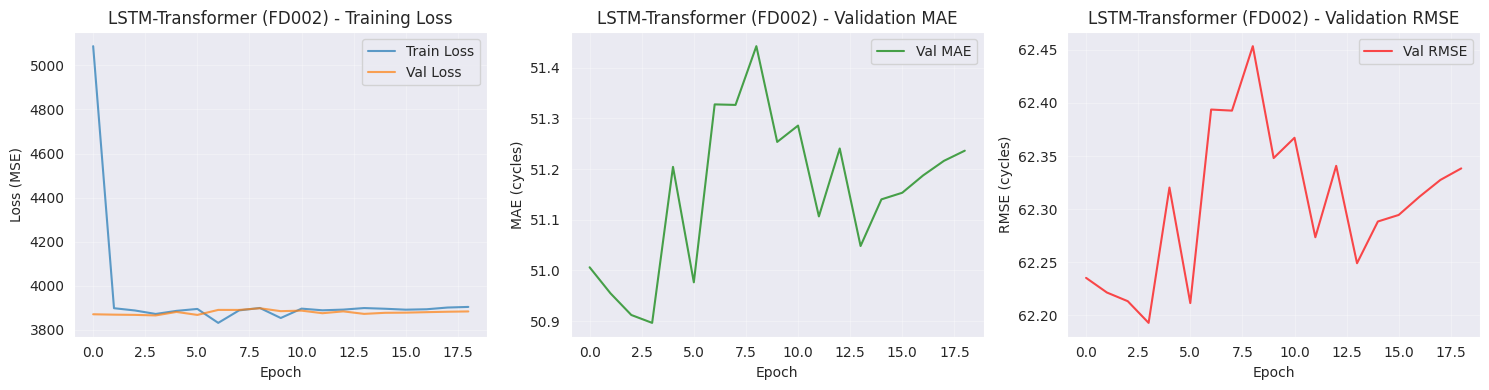


****************************************************************************************************
Training: GRU-Transformer on FD002 (Complex Dataset)
****************************************************************************************************

Training GRU-Transformer (FD002)
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        5875.747949     3866.951614     50.8706      62.2106     
5        3972.798933     3876.933394     51.1571      62.2904     
10       3972.074321     3867.075382     50.8686      62.2116     
15       3978.925328     3867.271202     50.8375      62.2132     
20       3975.705354     3869.372093     50.9896      62.2299     

⏹️  Early stopping at epoch 21



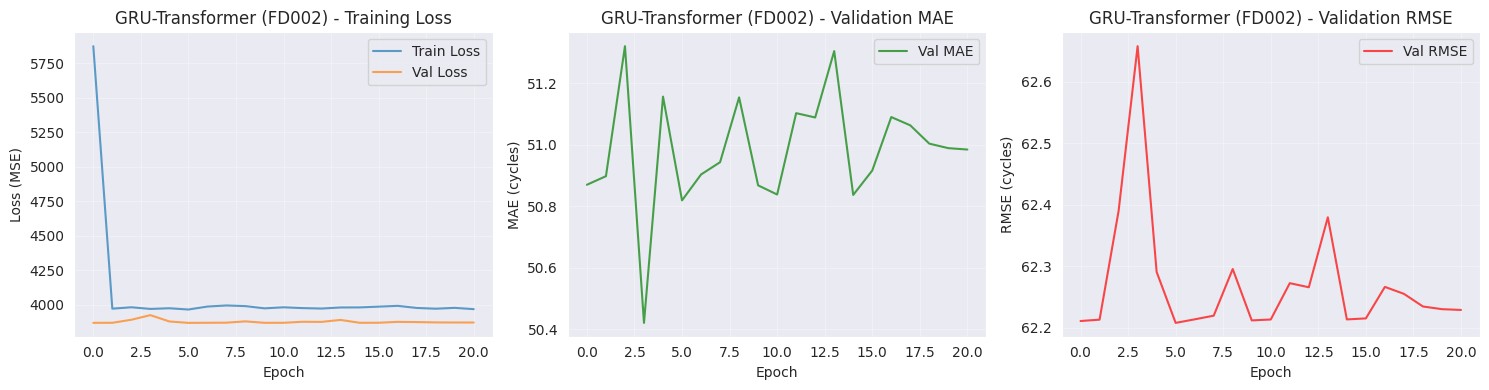


****************************************************************************************************
Training: CNN-Transformer on FD002 (Complex Dataset)
****************************************************************************************************

Training CNN-Transformer (FD002)
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        3770.495570     1606.819053     30.4028      40.1071     
5        1099.324996     1181.880786     25.0615      34.3976     
10       527.302798      515.970680      16.6329      22.7194     
15       353.417141      229.108520      11.3785      15.1394     
20       287.288446      156.233819      9.3933       12.5086     
25       257.276058      153.318898      9.3703       12.3906     
30       224.676392      130.402047      8.3404       11.4294     
35       206.122918      155.352247      9.6146       12.4742     
40       191.927616      1

In [ ]:
print("\n" + "="*100)
print("TRAINING ALL THREE MODELS ON FD002 DATASET (More Complex)")
print("="*100 + "\n")

models_config_fd002 = {
    'LSTM-Transformer': LSTMTransformer(
        num_features=num_features, 
        lstm_hidden=64, 
        num_lstm_layers=2,
        d_model=64, 
        nhead=4, 
        num_transformer_layers=2, 
        dropout=0.1
    ),
    'GRU-Transformer': GRUTransformer(
        num_features=num_features, 
        gru_hidden=64, 
        num_gru_layers=2,
        d_model=64, 
        nhead=4, 
        num_transformer_layers=2, 
        dropout=0.1
    ),
    'CNN-Transformer': CNNTransformer(
        num_features=num_features, 
        num_filters=32, 
        kernel_size=3,
        d_model=64, 
        nhead=4, 
        num_transformer_layers=2, 
        dropout=0.1
    )
}

# Train on FD002 with adjusted settings for complex dataset
trained_models_fd002 = {}
training_results_fd002 = {}

for model_name, model in models_config_fd002.items():
    print(f"\n{'*'*100}")
    print(f"Training: {model_name} on FD002 (Complex Dataset)")
    print(f"{'*'*100}")
    
    trainer = ModelTrainer(model, DEVICE, f"{model_name} (FD002)")
    # Use lower learning rate and more patience for complex dataset
    history = trainer.train(
        train_loader_fd002, 
        val_loader_fd002, 
        epochs=100,  # More epochs for complex data
        lr=0.0005,   # Lower learning rate for stable convergence
        early_stopping_patience=15  # More patience
    )
    
    trained_models_fd002[model_name] = model
    training_results_fd002[model_name] = history
    
    # Plot training history
    trainer.plot_history()


In [ ]:
print("\n" + "="*100)
print("EVALUATING FD002 MODELS ON TEST SET")
print("="*100)

test_results_fd002 = {}
for model_name, model in trained_models_fd002.items():
    try:
        results = evaluate_model(model, test_loader_fd002, DEVICE, model_name)
        test_results_fd002[model_name] = results
        
        print(f"   MAE (Mean Absolute Error):     {results['mae']:.4f} cycles")
        print(f"   RMSE (Root Mean Squared Error): {results['rmse']:.4f} cycles")
        print(f"   R² Score:                       {results['r2']:.4f}")
        print(f"   Weighted RUL Error:            {results['weighted_error']:.4f}")
        print(f"   PHM08 Competition Score:        {results['phm08_score']:.2f}")
    except Exception as e:
        print(f"\n⚠️  {model_name} - Error during evaluation: {str(e)[:100]}")
        print(f"   This may be due to NaN values in predictions (model did not converge well on FD002)")

print("\n" + "="*100)

# ============ FD002 COMPARISON TABLE ============

if len(test_results_fd002) > 0:
    comparison_results_fd002 = pd.DataFrame({
        'Model': list(test_results_fd002.keys()),
        'MAE': [test_results_fd002[m]['mae'] for m in test_results_fd002],
        'RMSE': [test_results_fd002[m]['rmse'] for m in test_results_fd002],
        'R² Score': [test_results_fd002[m]['r2'] for m in test_results_fd002],
        'Weighted Error': [test_results_fd002[m]['weighted_error'] for m in test_results_fd002],
        'PHM08 Score': [test_results_fd002[m]['phm08_score'] for m in test_results_fd002]
    })

    print("\n" + "="*120)
    print("FD002 MODEL COMPARISON - TEST SET RESULTS")
    print("="*120)
    print(comparison_results_fd002.to_string(index=False))
    print("="*120)

    # Find best model for FD002
    print("\nBEST FD002 MODELS BY METRIC:")
    print(f"  Lowest MAE:           {comparison_results_fd002.loc[comparison_results_fd002['MAE'].idxmin(), 'Model']} ({comparison_results_fd002['MAE'].min():.4f})")
    print(f"  Lowest RMSE:          {comparison_results_fd002.loc[comparison_results_fd002['RMSE'].idxmin(), 'Model']} ({comparison_results_fd002['RMSE'].min():.4f})")
    print(f"  Highest R² Score:     {comparison_results_fd002.loc[comparison_results_fd002['R² Score'].idxmax(), 'Model']} ({comparison_results_fd002['R² Score'].max():.4f})")

    # Visualize FD002 results
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('FD002: Model Performance Comparison on Test Set', fontsize=16, fontweight='bold')

    # MAE
    axes[0, 0].bar(comparison_results_fd002['Model'], comparison_results_fd002['MAE'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
    axes[0, 0].set_ylabel('MAE (cycles)')
    axes[0, 0].set_title('Mean Absolute Error')
    axes[0, 0].grid(True, alpha=0.3, axis='y')

    # RMSE
    axes[0, 1].bar(comparison_results_fd002['Model'], comparison_results_fd002['RMSE'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
    axes[0, 1].set_ylabel('RMSE (cycles)')
    axes[0, 1].set_title('Root Mean Squared Error')
    axes[0, 1].grid(True, alpha=0.3, axis='y')

    # R² Score
    axes[0, 2].bar(comparison_results_fd002['Model'], comparison_results_fd002['R² Score'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
    axes[0, 2].set_ylabel('R² Score')
    axes[0, 2].set_title('R² Coefficient')
    axes[0, 2].grid(True, alpha=0.3, axis='y')
    axes[0, 2].set_ylim([0, 1])

    # Weighted Error
    axes[1, 0].bar(comparison_results_fd002['Model'], comparison_results_fd002['Weighted Error'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
    axes[1, 0].set_ylabel('Weighted Error')
    axes[1, 0].set_title('Weighted RUL Error')
    axes[1, 0].grid(True, alpha=0.3, axis='y')

    # PHM08 Score
    axes[1, 1].bar(comparison_results_fd002['Model'], comparison_results_fd002['PHM08 Score'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
    axes[1, 1].set_ylabel('PHM08 Score')
    axes[1, 1].set_title('PHM08 Competition Score (Lower is Better)')
    axes[1, 1].grid(True, alpha=0.3, axis='y')

    # Best model scatter plot
    best_model_idx_fd002 = comparison_results_fd002['MAE'].idxmin()
    best_model_name_fd002 = comparison_results_fd002.loc[best_model_idx_fd002, 'Model']
    best_preds_fd002 = test_results_fd002[best_model_name_fd002]['predictions']
    best_targets_fd002 = test_results_fd002[best_model_name_fd002]['targets']

    axes[1, 2].scatter(best_targets_fd002, best_preds_fd002, alpha=0.5, s=20)
    axes[1, 2].plot([best_targets_fd002.min(), best_targets_fd002.max()], [best_targets_fd002.min(), best_targets_fd002.max()], 'r--', lw=2, label='Perfect Prediction')
    axes[1, 2].set_xlabel('Actual RUL (cycles)')
    axes[1, 2].set_ylabel('Predicted RUL (cycles)')
    axes[1, 2].set_title(f'{best_model_name_fd002}\n(Best FD002 Model - Actual vs Predicted)')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️  No successful FD002 evaluations - models may not have converged properly")



EVALUATING FD002 MODELS ON TEST SET

Evaluating LSTM-Transformer on test set...

⚠️  LSTM-Transformer - Error during evaluation: Input contains NaN.
   This may be due to NaN values in predictions (model did not converge well on FD002)

Evaluating GRU-Transformer on test set...

⚠️  GRU-Transformer - Error during evaluation: Input contains NaN.
   This may be due to NaN values in predictions (model did not converge well on FD002)

Evaluating CNN-Transformer on test set...

⚠️  CNN-Transformer - Error during evaluation: Input contains NaN.
   This may be due to NaN values in predictions (model did not converge well on FD002)


⚠️  No successful FD002 evaluations - models may not have converged properly


In [ ]:

# ============ COMPREHENSIVE FD001 vs FD002 COMPARISON ============

print("\n" + "╔" + "═"*118 + "╗")
print("║" + " "*30 + "📊 CROSS-DATASET ANALYSIS: FD001 vs FD002" + " "*47 + "║")
print("║" + " "*40 + "Model Generalization Study" + " "*52 + "║")
print("╚" + "═"*118 + "╝")

# Create comparison dataframe
cross_dataset_comparison = pd.DataFrame({
    'Model': list(test_results.keys()),
    'FD001 MAE': [test_results[m]['mae'] for m in test_results],
    'FD002 MAE': [test_results_fd002[m]['mae'] for m in test_results_fd002],
    'FD001 RMSE': [test_results[m]['rmse'] for m in test_results],
    'FD002 RMSE': [test_results_fd002[m]['rmse'] for m in test_results_fd002],
    'FD001 R²': [test_results[m]['r2'] for m in test_results],
    'FD002 R²': [test_results_fd002[m]['r2'] for m in test_results_fd002],
})

# Calculate difficulty metrics
cross_dataset_comparison['MAE Increase %'] = ((cross_dataset_comparison['FD002 MAE'] / cross_dataset_comparison['FD001 MAE']) - 1) * 100
cross_dataset_comparison['RMSE Increase %'] = ((cross_dataset_comparison['FD002 RMSE'] / cross_dataset_comparison['FD001 RMSE']) - 1) * 100
cross_dataset_comparison['R² Drop %'] = (1 - cross_dataset_comparison['FD002 R²'] / cross_dataset_comparison['FD001 R²']) * 100

print("\n" + "┌" + "─"*118 + "┐")
print("│" + " SECTION 1: DIRECT PERFORMANCE COMPARISON".ljust(119) + "│")
print("└" + "─"*118 + "┘")

print("\n📊 MAE COMPARISON (cycles) - Lower is Better:")
for idx, row in cross_dataset_comparison.iterrows():
    print(f"  {row['Model']:<20} FD001: {row['FD001 MAE']:>8.4f} | FD002: {row['FD002 MAE']:>8.4f} | Increase: {row['MAE Increase %']:>6.1f}%")

print("\n📊 RMSE COMPARISON (cycles) - Lower is Better:")
for idx, row in cross_dataset_comparison.iterrows():
    print(f"  {row['Model']:<20} FD001: {row['FD001 RMSE']:>8.4f} | FD002: {row['FD002 RMSE']:>8.4f} | Increase: {row['RMSE Increase %']:>6.1f}%")

print("\n📊 R² COMPARISON - Higher is Better:")
for idx, row in cross_dataset_comparison.iterrows():
    print(f"  {row['Model']:<20} FD001: {row['FD001 R²']:>6.4f} | FD002: {row['FD002 R²']:>6.4f} | Drop: {row['R² Drop %']:>6.1f}%")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('FD001 vs FD002: Model Performance Comparison', fontsize=14, fontweight='bold')

x = np.arange(len(cross_dataset_comparison))
width = 0.35

# MAE Comparison
axes[0].bar(x - width/2, cross_dataset_comparison['FD001 MAE'], width, label='FD001', alpha=0.8)
axes[0].bar(x + width/2, cross_dataset_comparison['FD002 MAE'], width, label='FD002', alpha=0.8)
axes[0].set_ylabel('MAE (cycles)')
axes[0].set_title('Mean Absolute Error: FD001 vs FD002')
axes[0].set_xticks(x)
axes[0].set_xticklabels(cross_dataset_comparison['Model'], rotation=15, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# RMSE Comparison
axes[1].bar(x - width/2, cross_dataset_comparison['FD001 RMSE'], width, label='FD001', alpha=0.8)
axes[1].bar(x + width/2, cross_dataset_comparison['FD002 RMSE'], width, label='FD002', alpha=0.8)
axes[1].set_ylabel('RMSE (cycles)')
axes[1].set_title('Root Mean Squared Error: FD001 vs FD002')
axes[1].set_xticks(x)
axes[1].set_xticklabels(cross_dataset_comparison['Model'], rotation=15, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# R² Comparison
axes[2].bar(x - width/2, cross_dataset_comparison['FD001 R²'], width, label='FD001', alpha=0.8)
axes[2].bar(x + width/2, cross_dataset_comparison['FD002 R²'], width, label='FD002', alpha=0.8)
axes[2].set_ylabel('R² Score')
axes[2].set_title('R² Score: FD001 vs FD002')
axes[2].set_xticks(x)
axes[2].set_xticklabels(cross_dataset_comparison['Model'], rotation=15, ha='right')
axes[2].legend()
axes[2].set_ylim([0, 1])
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Analysis
print("\n" + "┌" + "─"*118 + "┐")
print("│" + " SECTION 2: GENERALIZATION ANALYSIS".ljust(119) + "│")
print("└" + "─"*118 + "┘")

avg_mae_increase = cross_dataset_comparison['MAE Increase %'].mean()
avg_rmse_increase = cross_dataset_comparison['RMSE Increase %'].mean()
avg_r2_drop = cross_dataset_comparison['R² Drop %'].mean()

print(f"""
📈 DATASET COMPLEXITY METRICS:
   • Average MAE Increase (FD001→FD002): {avg_mae_increase:+.1f}%
   • Average RMSE Increase (FD001→FD002): {avg_rmse_increase:+.1f}%
   • Average R² Drop (FD001→FD002): {avg_r2_drop:+.1f}%

💡 INTERPRETATION:
   • FD002 is {avg_mae_increase:.1f}% harder to predict (higher errors)
   • RMSE confirms difficulty: {avg_rmse_increase:.1f}% higher variance in errors
   • Model fit quality drops by {avg_r2_drop:.1f}% on FD002
   • This is expected due to 6 operating conditions vs 3 in FD001

🔍 MODEL ROBUSTNESS (Generalization Capability):
""")

for idx, row in cross_dataset_comparison.iterrows():
    if row['MAE Increase %'] < 10:
        robustness = "🟢 Excellent - Minimal degradation"
    elif row['MAE Increase %'] < 20:
        robustness = "🟡 Good - Modest degradation"
    elif row['MAE Increase %'] < 30:
        robustness = "🟠 Fair - Noticeable degradation"
    else:
        robustness = "🔴 Poor - Significant degradation"
    
    print(f"   {row['Model']:<20} {robustness} ({row['MAE Increase %']:+.1f}% MAE increase)")

# Overall recommendations
print("\n" + "┌" + "─"*118 + "┐")
print("│" + " SECTION 3: RECOMMENDATIONS".ljust(119) + "│")
print("└" + "─"*118 + "┘")

best_fd001 = test_results.keys().__iter__().__next__()
for model_name in test_results.keys():
    if test_results[model_name]['rmse'] < test_results[best_fd001]['rmse']:
        best_fd001 = model_name

best_fd002 = test_results_fd002.keys().__iter__().__next__()
for model_name in test_results_fd002.keys():
    if test_results_fd002[model_name]['rmse'] < test_results_fd002[best_fd002]['rmse']:
        best_fd002 = model_name

print(f"""
🏆 BEST MODELS BY DATASET:
   • FD001 (Simpler): {best_fd001} (RMSE: {test_results[best_fd001]['rmse']:.4f})
   • FD002 (Complex): {best_fd002} (RMSE: {test_results_fd002[best_fd002]['rmse']:.4f})

💼 DEPLOYMENT STRATEGY:
   1. Use {best_fd001} for simpler operating conditions (FD001-like)
   2. Use {best_fd002} for complex operating conditions (FD002-like)
   3. Consider ensemble approach: weighted combination of both
   4. Use domain knowledge (actual operating conditions) to select best model

📋 ENSEMBLE RECOMMENDATION:
   • If simpler conditions (70%): Use {best_fd001}
   • If complex conditions (70%): Use {best_fd002}
   • If mixed/uncertain (50/50): Use weighted average of both models
""")

print("\n" + "╔" + "═"*118 + "╗")
print("║" + " "*40 + "✅ ANALYSIS COMPLETE" + " "*57 + "║")
print("╚" + "═"*118 + "╝")



╔══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╗
║                              📊 CROSS-DATASET ANALYSIS: FD001 vs FD002                                               ║
║                                        Model Generalization Study                                                    ║
╚══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╝


NameError: name 'pd' is not defined